## Data & Preprocessing

This section documents the complete data pipeline for constructing the multi-channel feature tensor and binary target mask required for the topographically aware U-Net semantic segmentation model. The pipeline fuses passive optical satellite imagery, topographic derivatives, and civic vector data to enable precise spatial delineation of destroyed urban infrastructure and severe vegetative canopy loss following the January 2025 Palisades Fire event.

[LA Building Footprints](https://github.com/microsoft/USBuildingFootprints)

[LA CAL FIRE DINS Post-Fire Damage Palisades](https://gis.data.cnra.ca.gov/datasets/CALFIRE-Forestry::cal-fire-damage-inspection-dins-data/explore?filters=eyJJTkNJREVOVE5BTUUiOlsiUGFsaXNhZGVzIl19&location=34.063668%2C-118.567981%2C12)

[LA NIFC FIRIS Palisades Perimeter](https://data.lacounty.gov/datasets/lacounty::palisades-and-eaton-dissolved-fire-perimeters-2025/explore?layer=1&location=34.076488%2C-118.572565%2C11)

### Environment Setup and Dependencies

In [ ]:
# COLAB DRIVE MOUNT
# Uncomment if running in Google Colab.
#from google.colab import drive
#drive.mount("/content/drive")
#import os
#os.chdir("/content/drive/MyDrive/Colab Notebooks/wui_fires")

Mounted at /content/drive


In [ ]:
#!pip install odc-stac geopandas folium contextily rioxarray pystac-client planetary-computer scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 564.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [3]:
# CORE LIBRARIES
import os
import json
import warnings
import geopandas as gpd
import numpy as np
import odc.stac
import folium
import contextily as ctx
import rioxarray
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer
from IPython.display import Image
from rasterio.errors import NotGeoreferencedWarning

# STAC AND ODC MODULES
import planetary_computer
from pystac_client import Client
from rasterio import features
from rasterio.transform import from_bounds
from shapely.geometry import box

# SKIMAGE FOR OTSU THRESHOLDING
from skimage.filters import threshold_otsu

In [4]:
# DISPLAY AND SAVE FIGURES AT 300 DPI
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

# CREATE FOLDER FOR FINAL PROJECT
final_project_path = Path("final_project_files")
final_project_path.mkdir(parents=True, exist_ok=True)

# CREATE FOLDER FOR IMAGES
images_path = Path("final_project_files/images")
images_path.mkdir(parents=True, exist_ok=True)

### Study Area and Temporal Range

The Palisades Fire ignited on January 7, 2025, and burned through steep, chaparral-dense canyons in the Santa Monica Mountains directly into densely populated residential areas of Pacific Palisades. The bounding box encompasses the primary fire impact zone within the Wildland-Urban Interface (WUI).

In [5]:
# STUDY AREA BOUNDING BOX
# Bounding box covers Pacific Palisades fire perimeter in WGS84 coordinates.
# [min_longitude, min_latitude, max_longitude, max_latitude].
palisades_bbox = [-118.717856, 33.998365, -118.466523, 34.139426]

# TEMPORAL RANGE
# Pre-fire window captures baseline conditions before January 7, 2025.
pre_fire_start = "2024-12-01"
pre_fire_end = "2025-01-06"

# Post-fire window captures burn scar conditions after fire containment.
post_fire_start = "2025-02-01"
post_fire_end = "2025-02-28"

# TARGET CRS FOR ALL DATA
# UTM Zone 11N is projected coordinate system for Los Angeles.
target_crs = "EPSG:32611"

# TARGET SPATIAL RESOLUTION
# Sentinel-2 NIR band (B8A) has 20m native resolution.
target_resolution = 20

### Satellite Data via STAC API

This step queries the Element 84 Earth Search STAC API to retrieve Sentinel-2 Level-2A surface reflectance imagery. The required bands are B8A (Near-Infrared at 20m) and B12 (Shortwave-Infrared at 20m) for Normalized Burn Ratio calculation, along with SCL (Scene Classification Layer) for cloud and shadow masking.

In [6]:
# CONNECT TO ELEMENT 84 EARTH SEARCH STAC CATALOG
# Element 84 provides open access to Sentinel-2 L2A data without authentication.
stac_catalog_url = "https://earth-search.aws.element84.com/v1"
catalog = Client.open(stac_catalog_url)

In [7]:
# PRE-FIRE SENTINEL-2 IMAGERY
# Cloud cover threshold set to 30% to balance data availability and quality.
pre_fire_search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=palisades_bbox,
    datetime=f"{pre_fire_start}/{pre_fire_end}",
    query={"eo:cloud_cover": {"lt": 30}},
)

pre_fire_items = list(pre_fire_search.item_collection())

print(f"Pre-Fire Scenes: {len(pre_fire_items)}")

# SCENE METADATA
for item in pre_fire_items:
    cloud_cover = item.properties.get("eo:cloud_cover", "N/A")
    print(
        f"Scene: {item.id} | Date: {item.datetime.strftime('%Y-%m-%d')} | Cloud Cover: {cloud_cover:.1f}%"
    )

Pre-Fire Scenes: 3
Scene: S2A_11SLT_20250102_0_L2A | Date: 2025-01-02 | Cloud Cover: 3.0%
Scene: S2B_11SLT_20241218_0_L2A | Date: 2024-12-18 | Cloud Cover: 0.0%
Scene: S2A_11SLT_20241213_0_L2A | Date: 2024-12-13 | Cloud Cover: 21.5%


In [8]:
# POST-FIRE SENTINEL-2 IMAGERY
# Post-fire scenes capture burn scar and destroyed infrastructure.
post_fire_search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=palisades_bbox,
    datetime=f"{post_fire_start}/{post_fire_end}",
    query={"eo:cloud_cover": {"lt": 30}},
)

post_fire_items = list(post_fire_search.item_collection())

print(f"Post-Fire Scenes: {len(post_fire_items)}")

# SCENE METADATA
for item in post_fire_items:
    cloud_cover = item.properties.get("eo:cloud_cover", "N/A")
    print(
        f"Scene: {item.id} | Date: {item.datetime.strftime('%Y-%m-%d')} | Cloud Cover: {cloud_cover:.1f}%"
    )

Post-Fire Scenes: 2
Scene: S2C_11SLT_20250221_0_L2A | Date: 2025-02-21 | Cloud Cover: 5.0%
Scene: S2C_11SLT_20250201_0_L2A | Date: 2025-02-01 | Cloud Cover: 15.8%


In [9]:
pre_fire_items[0]

<Item id=S2A_11SLT_20250102_0_L2A>

In [10]:
Image(url=pre_fire_items[0].assets["thumbnail"].href)

In [11]:
# SELECT OPTIMAL SCENES
# Select scene with lowest cloud cover from both.


def select_best_scene(items):
    """Select the scene with minimum cloud cover from a list of STAC items."""
    if not items:
        return None
    sorted_items = sorted(items, key=lambda x: x.properties.get("eo:cloud_cover", 100))
    return sorted_items[0]


best_pre_fire = select_best_scene(pre_fire_items)
best_post_fire = select_best_scene(post_fire_items)

print(f"Pre-Fire Scene: {best_pre_fire.id if best_pre_fire else 'None found'}")
print(f"Post-Fire Scene: {best_post_fire.id if best_post_fire else 'None found'}")

Pre-Fire Scene: S2B_11SLT_20241218_0_L2A
Post-Fire Scene: S2C_11SLT_20250221_0_L2A


In [12]:
# PRE-FIRE BANDS INTO XARRAY
# Required bands: B8A (NIR 20m), B12 (SWIR 20m), SCL (Scene Classification).
required_bands = ["nir08", "swir16", "scl"]

pre_fire_data = odc.stac.load(
    [best_pre_fire],
    bands=required_bands,
    bbox=palisades_bbox,
    resolution=target_resolution,
    crs=target_crs,
    chunks={"x": 512, "y": 512},
)

print(pre_fire_data)

<xarray.Dataset> Size: 5MB
Dimensions:      (y: 801, x: 1173, time: 1)
Coordinates:
  * y            (y) float64 6kB 3.779e+06 3.779e+06 ... 3.763e+06 3.763e+06
  * x            (x) float64 9kB 3.414e+05 3.414e+05 ... 3.648e+05 3.648e+05
  * time         (time) datetime64[ns] 8B 2024-12-18T18:45:03.766000
    spatial_ref  int32 4B 32611
Data variables:
    nir08        (time, y, x) uint16 2MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swir16       (time, y, x) uint16 2MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    scl          (time, y, x) uint8 940kB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>


In [13]:
pre_fire_data

<xarray.Dataset> Size: 5MB
Dimensions:      (y: 801, x: 1173, time: 1)
Coordinates:
  * y            (y) float64 6kB 3.779e+06 3.779e+06 ... 3.763e+06 3.763e+06
  * x            (x) float64 9kB 3.414e+05 3.414e+05 ... 3.648e+05 3.648e+05
  * time         (time) datetime64[ns] 8B 2024-12-18T18:45:03.766000
    spatial_ref  int32 4B 32611
Data variables:
    nir08        (time, y, x) uint16 2MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swir16       (time, y, x) uint16 2MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    scl          (time, y, x) uint8 940kB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

In [14]:
# POST-FIRE BANDS INTO XARRAY
# Same band configuration as pre-fire for consistent analysis.
post_fire_data = odc.stac.load(
    [best_post_fire],
    bands=required_bands,
    bbox=palisades_bbox,
    resolution=target_resolution,
    crs=target_crs,
    chunks={"x": 512, "y": 512},
)

print(post_fire_data)

<xarray.Dataset> Size: 5MB
Dimensions:      (y: 801, x: 1173, time: 1)
Coordinates:
  * y            (y) float64 6kB 3.779e+06 3.779e+06 ... 3.763e+06 3.763e+06
  * x            (x) float64 9kB 3.414e+05 3.414e+05 ... 3.648e+05 3.648e+05
  * time         (time) datetime64[ns] 8B 2025-02-21T18:45:25.463000
    spatial_ref  int32 4B 32611
Data variables:
    nir08        (time, y, x) uint16 2MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swir16       (time, y, x) uint16 2MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    scl          (time, y, x) uint8 940kB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>


In [15]:
post_fire_data

<xarray.Dataset> Size: 5MB
Dimensions:      (y: 801, x: 1173, time: 1)
Coordinates:
  * y            (y) float64 6kB 3.779e+06 3.779e+06 ... 3.763e+06 3.763e+06
  * x            (x) float64 9kB 3.414e+05 3.414e+05 ... 3.648e+05 3.648e+05
  * time         (time) datetime64[ns] 8B 2025-02-21T18:45:25.463000
    spatial_ref  int32 4B 32611
Data variables:
    nir08        (time, y, x) uint16 2MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swir16       (time, y, x) uint16 2MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    scl          (time, y, x) uint8 940kB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

In [16]:
# SENTINEL-2 SCENE CLASSIFICATION CLOUD MASK
# Valid SCL Classes: 2 = Dark Area Pixels, 4 = Vegetation, 5 = Bare Soils,
# 6 = Water, 7 = Unclassified, 11 = Snow/Ice.
# Classes to Mask: 0 = No Data, 1 = Saturated, 3 = Cloud Shadow,
# 8 = Cloud Medium, 9 = Cloud High, 10 = Thin Cirrus.
valid_scl_classes = [2, 4, 5, 6, 7, 11]


def apply_scl_mask(data, valid_classes):
    """Apply SCL-based cloud and shadow mask to optical bands."""
    scl = data["scl"].squeeze()
    valid_mask = scl.isin(valid_classes)
    masked_nir = data["nir08"].where(valid_mask)
    masked_swir = data["swir16"].where(valid_mask)
    return masked_nir.squeeze(), masked_swir.squeeze(), valid_mask


# APPLY MASK TO PRE-FIRE DATA
pre_nir, pre_swir, pre_valid_mask = apply_scl_mask(pre_fire_data, valid_scl_classes)

# APPLY MASK TO POST-FIRE DATA
post_nir, post_swir, post_valid_mask = apply_scl_mask(post_fire_data, valid_scl_classes)

print(f"Pre-Fire Valid Pixel %: {float(pre_valid_mask.mean()) * 100:.1f}%")
print(f"Post-Fire Valid Pixel %: {float(post_valid_mask.mean()) * 100:.1f}%")

Pre-Fire Valid Pixel %: 100.0%
Post-Fire Valid Pixel %: 96.0%


### Calculate Normalized Burn Ratio and Delta NBR

The Normalized Burn Ratio (NBR) is calculated using Near-Infrared (NIR) and Shortwave-Infrared (SWIR) bands. The delta NBR (dNBR) quantifies the change in burn severity between pre-fire and post-fire conditions. Higher dNBR values indicate more severe burn damage.

In [17]:
# NORMALIZED BURN RATIO CALCULATION FUNCTION
# NBR = (NIR - SWIR) / (NIR + SWIR).
# Epsilon term prevents division by zero in dark or saturated pixels.


def calc_nbr(nir, swir, epsilon=1e-10):
    """Calculate Normalized Burn Ratio from NIR and SWIR bands."""
    nir = nir.astype(float)
    swir = swir.astype(float)
    nbr = (nir - swir) / (nir + swir + epsilon)
    return nbr


# PRE-FIRE NBR
nbr_pre = calc_nbr(pre_nir, pre_swir)

# POST-FIRE NBR
nbr_post = calc_nbr(post_nir, post_swir)

print(f"Pre-Fire NBR Range: [{float(nbr_pre.min()):.3f}, {float(nbr_pre.max()):.3f}]")
print(
    f"Post-Fire NBR Range: [{float(nbr_post.min()):.3f}, {float(nbr_post.max()):.3f}]"
)

Pre-Fire NBR Range: [-0.995, 0.996]
Post-Fire NBR Range: [-0.987, 0.682]


In [18]:
# Plot pre-fire and post-fire NBR side by side.
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Pre-fire NBR.
pre_fire_plot = axes[0].imshow(nbr_pre.values, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("Pre-Fire NBR (Healthy Vegetation)", fontsize=14, fontweight="bold")
axes[0].xaxis.set_visible(False)
axes[0].yaxis.set_visible(False)
cbar0 = plt.colorbar(pre_fire_plot, ax=axes[0], fraction=0.05)
cbar0.set_label("NBR", rotation=270, labelpad=15)

# Post-fire NBR.
post_fire_plot = axes[1].imshow(nbr_post.values, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title("Post-Fire NBR (Burn Damage)", fontsize=14, fontweight="bold")
axes[1].xaxis.set_visible(False)
axes[1].yaxis.set_visible(False)
cbar1 = plt.colorbar(post_fire_plot, ax=axes[1], fraction=0.05)
cbar1.set_label("NBR", rotation=270, labelpad=15)

plt.suptitle(
    "Palisades Fire Area: Normalized Burn Ratio (NBR)",
    fontsize=16,
    fontweight="bold",
    y=1,
)
plt.tight_layout()
plt.savefig(
    "final_project_files/images/nbr_comparison.png", dpi=300, bbox_inches="tight"
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

![](dNBR_thresholds.png "USGS dNBR Thresholds")

In [19]:
# DELTA NORMALIZED BURN RATIO
# dNBR = NBR_pre - NBR_post.
# Positive dNBR indicates vegetation loss or burn damage.
# USGS dNBR Thresholds: High Regrowth = -0.500 - -0.251,
# Low Regrowth = -0.250 - -0.101, Unburned = -0.100 - 0.99,
# Low = 0.100 - 0.269, Moderate-Low = 0.270 - 0.439,
# Moderate-High = 0.44 - 0.659, High > 0.66.
dnbr = nbr_pre - nbr_post

# COMBINE VALID MASKS FROM BOTH TEMPORAL WINDOWS
# Pixels must be valid in both pre-fire and post-fire scenes.
combined_valid_mask = pre_valid_mask & post_valid_mask
dnbr_masked = dnbr.where(combined_valid_mask)

print(f"dNBR Range: [{float(dnbr_masked.min()):.3f}, {float(dnbr_masked.max()):.3f}]")
print(f"Combined Valid Pixel %: {float(combined_valid_mask.mean()) * 100:.1f}%")

dNBR Range: [-1.553, 1.212]
Combined Valid Pixel %: 96.0%


In [20]:
# Plot pre-fire NBR, post-fire NBR, and dNBR.
fig, axes = plt.subplots(3, 1, figsize=(8, 16))

# Pre-fire NBR.
pre_fire_plot = axes[0].imshow(nbr_pre.values, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("Pre-Fire NBR (Healthy Vegetation)", fontsize=14, fontweight="bold")
axes[0].xaxis.set_visible(False)
axes[0].yaxis.set_visible(False)
cbar0 = plt.colorbar(pre_fire_plot, ax=axes[0], fraction=0.05)
cbar0.set_label("NBR", rotation=270, labelpad=15)

# Post-fire NBR.
post_fire_plot = axes[1].imshow(nbr_post.values, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title("Post-Fire NBR (Burn Damage)", fontsize=14, fontweight="bold")
axes[1].xaxis.set_visible(False)
axes[1].yaxis.set_visible(False)
cbar1 = plt.colorbar(post_fire_plot, ax=axes[1], fraction=0.05)
cbar1.set_label("NBR", rotation=270, labelpad=15)

# dNBR.
dnbr_plot = axes[2].imshow(dnbr.values, cmap="RdYlGn_r", vmin=-1, vmax=1)
axes[2].set_title(
    "dNBR (Pre-Fire and Post-Fire NBR Difference)", fontsize=14, fontweight="bold"
)
axes[2].xaxis.set_visible(False)
axes[2].yaxis.set_visible(False)
cbar2 = plt.colorbar(dnbr_plot, ax=axes[2], fraction=0.05)
cbar2.set_label("dNBR", rotation=270, labelpad=15)

plt.suptitle(
    "Palisades Fire Area: Normalized Burn Ratio (NBR) and Difference (dNBR)",
    fontsize=16,
    fontweight="bold",
    y=1,
)
plt.tight_layout()
plt.savefig(
    "final_project_files/images/dnbr_comparison.png", dpi=300, bbox_inches="tight"
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [21]:
# GET SPATIAL REFERENCE INFORMATION FROM SENTINEL DATA
# Metadata will be used to align all following datasets.
sentinel_crs = post_fire_data.rio.crs
sentinel_bounds = post_fire_data.rio.bounds()
sentinel_shape = (post_fire_data.sizes["y"], post_fire_data.sizes["x"])
sentinel_transform = post_fire_data.rio.transform()

print(f"CRS: {sentinel_crs}")
print(f"Bounds: {sentinel_bounds}")
print(f"Shape (rows, cols): {sentinel_shape}")
print(f"Transform:\n{sentinel_transform}")

CRS: EPSG:32611
Bounds: (341340.0, 3762940.0, 364800.0, 3778960.0)
Shape (rows, cols): (801, 1173)
Transform:
| 20.00, 0.00, 341340.00|
| 0.00,-20.00, 3778960.00|
| 0.00, 0.00, 1.00|


### Topographic Ancillary Data

The USGS 3DEP 10m Digital Elevation Model is processed to derive the Aspect array. Aspect indicates the compass direction that a slope faces, which is critical for addressing the topographic shadow failure mode. North-facing slopes in January receive less direct sunlight and appear darker in optical imagery, potentially causing false-positive burn classifications.

In [22]:
# QUERY USGS 3DEP DEM VIA STAC API
# The 3DEP 1m and 10m DEMs are available through Planetary Computer.
dem_catalog_url = "https://planetarycomputer.microsoft.com/api/stac/v1"
dem_catalog = Client.open(dem_catalog_url, modifier=planetary_computer.sign_inplace)

# SEARCH FOR 10M DEM TILES
dem_search = dem_catalog.search(collections=["3dep-seamless"], bbox=palisades_bbox)

dem_items = list(dem_search.item_collection())

print(f"DEM Tiles: {len(dem_items)}")

DEM Tiles: 4


In [23]:
dem_items[0]

<Item id=n35w119-13>

In [24]:
Image(url=dem_items[0].assets["rendered_preview"].href)

In [25]:
# LOAD DEM AND REPROJECT TO MATCH SENTINEL
dem_data = odc.stac.load(
    dem_items,
    bands=["data"],
    bbox=palisades_bbox,
    resolution=target_resolution,
    crs=target_crs,
    chunks={"x": 512, "y": 512},
)

# GET ELEVATION ARRAY
elevation = dem_data["data"].squeeze()

print(
    f"Elevation Range: [{float(elevation.min()):.1f}m, {float(elevation.max()):.1f}m]"
)
print(f"DEM Shape: {elevation.shape}")

Elevation Range: [-0.4m, 852.3m]
DEM Shape: (2, 801, 1173)


Sentinel-2 data is a 2D spatial grid (Y, X). DEM is a 3D array (Item, Y, X).

The Palisades bounding box crossed USGS tile boundary so STAC API returned two 3DEP tiles. If odc.stac.load ingests them, it stacks them along a time-item dimension and the .squeeze() function only removes dimensions with a length of 1, but because there are 2 tiles the dimension would remain.

If a 3D DEM array is fed into a numpy.dstack alongside 2D arrays the tensor construction will fail. So the two tiles must be composited into a single flat layer before stacking.

In [26]:
# SUPRESS WARNINGS
warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

# MOSAIC OVERLAPPING ELEVATION TILES
# Reduce time dimension to flatten 3D array into 2D spatial grid.
elevation_raw = dem_data["data"].max(dim="time").squeeze()

# ASSIGN CRS TO RAW DEM
# rioxarray requires source array to have CRS before reprojecting.
elevation_raw = elevation_raw.rio.write_crs(target_crs)

# SQUEEZE TIME DIMENSION FROM SENTINEL ARRAYS
# Remove single-length time dimension from datasets.
# Forces Sentinel data to 2D spatial grid.
post_fire_spatial = post_fire_data.squeeze()

# REPROJECT DEM TO SENTINEL GRID
# Match post_fire_spatial target.
elevation_aligned = elevation_raw.rio.reproject_match(post_fire_spatial)

# Must be identical.
print("Sentinel Shape:", post_fire_spatial.sizes)
print("DEM Shape:", elevation_aligned.sizes)

Sentinel Shape: Frozen({'y': 801, 'x': 1173})
DEM Shape: Frozen({'y': 801, 'x': 1173})


In [27]:
# ASPECT FROM DEM
# Aspect computed using gradient in x and y directions.
# Result in degrees where 0 = North, 90 = East, 180 = South, and 270 = West.


def calculate_aspect(dem, cell_size):
    # Convert to numpy for gradient calculation.
    dem_array = dem.values

    # Calculate gradients using numpy gradient function.
    # Gradient returns rate of change in y direction first, then x.
    dy, dx = np.gradient(dem_array, cell_size)

    # Calculate aspect in radians, then convert to degrees.
    aspect_rad = np.arctan2(-dy, dx)
    aspect_deg = np.degrees(aspect_rad)

    # Convert from mathematical convention to compass.
    # Rotate 90 degrees and handle negative values.
    aspect_compass = (90.0 - aspect_deg) % 360.0

    return aspect_compass


# ASPECT ARRAY
# Pass spatially aligned DEM array into calculation.
aspect_array = calculate_aspect(elevation_aligned, target_resolution)

print(
    f"Aspect Range: [{np.nanmin(aspect_array):.1f}, {np.nanmax(aspect_array):.1f}] degrees"
)
print(f"Aspect Shape: {aspect_array.shape}")

Aspect Range: [0.0, 360.0] degrees
Aspect Shape: (801, 1173)


In [28]:
# NORMALIZE ASPECT FOR MODEL
# Convert aspect to sine and cosine to handle circular characteristics.
# Can also normalize to 0-1 range for direct input as alternative.
aspect_normalized = aspect_array / 360.0

print(
    f"Normalized Aspect Range: [{np.nanmin(aspect_normalized):.3f}, {np.nanmax(aspect_normalized):.3f}]"
)

Normalized Aspect Range: [0.000, 1.000]


### Vector Data Ingestion

Three vector datasets are required:
1. **NIFC Fire Perimeter**: Defines the Region of Interest (ROI) for analysis.
2. **LA County Building Footprints**: Provides WUI infrastructure context.
3. **CAL FIRE DINS Points**: Identifies structures classified as "destroyed" during damage inspection.

In [29]:
# LOAD NIFC PALISADES FIRE PERIMETER
# Source: LA County Open Data Portal.
# Defines the official fire containment boundary.

fire_perimeter_path = "final_project_files/data/NIFC_FIRIS_Palisades_Perimeter.geojson"

fire_perimeter_gdf = gpd.read_file(fire_perimeter_path)

print(fire_perimeter_gdf.columns)
print(f"Original CRS: {fire_perimeter_gdf.crs}")

Index(['OBJECTID', 'type', 'Shape__Area', 'Shape__Length', 'Acres',
       'geometry'],
      dtype='object')
Original CRS: EPSG:4326


In [30]:
fire_perimeter_gdf

,OBJECTID,type,Shape__Area,Shape__Length,Acres,geometry
0,1,Heat Perimeter,1.182082e+03,267.101144,None,"POLYGON ((-118.51962 34.03061, -118.51962 34.0..."
1,2,Heat Perimeter,2.222488e+03,185.498783,None,"POLYGON ((-118.51944 34.03176, -118.51944 34.0..."
2,3,Heat Perimeter,2.101172e+01,22.412814,None,"POLYGON ((-118.52011 34.03244, -118.52011 34.0..."
3,4,Heat Perimeter,2.149922e+02,76.639180,None,"POLYGON ((-118.52061 34.03235, -118.52063 34.0..."
4,5,Heat Perimeter,4.420345e+04,1569.259764,None,"POLYGON ((-118.5256 34.03302, -118.5256 34.033..."
5,6,Heat Perimeter,3.734375e+01,25.061294,None,"POLYGON ((-118.52286 34.03427, -118.52283 34.0..."
6,7,Heat Perimeter,1.183555e+02,46.890360,None,"POLYGON ((-118.52276 34.03435, -118.52273 34.0..."
7,8,Heat Perimeter,1.686719e+01,16.860287,None,"POLYGON ((-118.51818 34.03739, -118.5182 34.03..."
8,9,Heat Perimeter,1.766301e+03,264.850402,None,"POLYGON ((-118.53964 34.03715, -118.53971 34.0..."
9,10,Heat Perimeter,7.939795e+04,2620.515743,None,"POLYGON ((-118.51748 34.03607, -118.51752 34.0..."


In [31]:
# Plot fire perimeter with background tile.
fig, ax = plt.subplots(figsize=(14, 12))

# Reproject to Web Mercator (EPSG:3857) for tiles.
fire_perimeter_web = fire_perimeter_gdf.to_crs(epsg=3857)

# Get bounds and set axis limits.
bounds = fire_perimeter_web.total_bounds
ax.set_xlim(bounds[0] - 500, bounds[2] + 500)
ax.set_ylim(bounds[1] - 500, bounds[3] + 500)

# Add background tile.
ctx.add_basemap(
    ax,
    crs=fire_perimeter_web.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=13,
    attribution=False,
)

# Plot fire perimeter on top.
fire_perimeter_web.plot(
    ax=ax, alpha=0.5, edgecolor="red", facecolor="none", linewidth=2
)

# Remove axis ticks.
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

ax.set_title("Palisades Fire Perimeter", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "final_project_files/images/palisades_fire_perimeter.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [32]:
# LOAD LOS ANGELES COUNTY BUILDING FOOTPRINTS
# Source: Microsoft.
# Filter to study area extent to reduce data volume.
buildings_path = (
    "final_project_files/data/Microsoft_California_Building_Footprints_Filtered.geojson"
)

# Create bounding box geometry, expects tuple, not list.
bbox_geometry = box(
    palisades_bbox[0], palisades_bbox[1], palisades_bbox[2], palisades_bbox[3]
)

buildings_gdf = gpd.read_file(buildings_path, bbox=bbox_geometry, engine="pyogrio")

print(buildings_gdf.columns)
print(f"Original CRS: {buildings_gdf.crs}")

Index(['release', 'capture_dates_range', 'geometry'], dtype='object')
Original CRS: EPSG:4326


In [33]:
# Spatial join to find buildings that intersect with fire perimeter.
buildings_web = buildings_gdf.to_crs(epsg=3857)
buildings_filtered = gpd.sjoin(
    buildings_web, fire_perimeter_web, how="inner", predicate="intersects"
).drop(columns=["index_right"])

print(f"Original Buildings: {len(buildings_web)}")
print(f"Buildings Intersecting Fire Perimeter: {len(buildings_filtered)}")

Original Buildings: 45527
Buildings Intersecting Fire Perimeter: 9344


In [34]:
buildings_filtered

,release,capture_dates_range,geometry,OBJECTID,type,Shape__Area,Shape__Length,Acres
552,2,5/9/2018-3/13/2019,"POLYGON ((-13191697.625 4037053.963, -13191705...",24,Heat Perimeter,1.420688e+08,105530.363538,None
563,2,5/9/2018-3/13/2019,"POLYGON ((-13191801.709 4037153.534, -13191794...",24,Heat Perimeter,1.420688e+08,105530.363538,None
564,2,5/9/2018-3/13/2019,"POLYGON ((-13191808.944 4037083.794, -13191801...",24,Heat Perimeter,1.420688e+08,105530.363538,None
569,2,5/9/2018-3/13/2019,"POLYGON ((-13191857.48 4036156.119, -13191865....",24,Heat Perimeter,1.420688e+08,105530.363538,None
610,2,5/9/2018-3/13/2019,"POLYGON ((-13191967.129 4035930.258, -13191992...",24,Heat Perimeter,1.420688e+08,105530.363538,None
...,...,...,...,...,...,...,...,...
45439,2,4/22/2018-6/1/2018,"POLYGON ((-13208281.891 4033921.626, -13208287...",24,Heat Perimeter,1.420688e+08,105530.363538,None
45443,2,4/22/2018-6/1/2018,"POLYGON ((-13208569.541 4035194.126, -13208551...",24,Heat Perimeter,1.420688e+08,105530.363538,None
45450,2,4/22/2018-6/1/2018,"POLYGON ((-13208934.558 4034808.814, -13208921...",24,Heat Perimeter,1.420688e+08,105530.363538,None
45451,2,4/22/2018-6/1/2018,"POLYGON ((-13208965.727 4034098.816, -13208964...",24,Heat Perimeter,1.420688e+08,105530.363538,None


In [35]:
# Plot building footprints with background tile.
fig, ax = plt.subplots(figsize=(12, 12))

# Reproject to Web Mercator (EPSG:3857) for tiles.
buildings_web = buildings_gdf.to_crs(epsg=3857)

# Get bounds and set axis limits.
bounds = buildings_web.total_bounds
ax.set_xlim(bounds[0] - 500, bounds[2] + 500)
ax.set_ylim(bounds[1] - 500, bounds[3] + 500)

# Add background tile.
ctx.add_basemap(
    ax,
    crs=buildings_web.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=13,
    attribution=False,
)

# Plot building footprints on top.
buildings_web.plot(ax=ax, alpha=0.5, edgecolor="blue")

# Remove axis ticks.
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

ax.set_title("Palisades Building Footprints", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "final_project_files/images/palisades_building_footprints.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [36]:
# LOAD CAL FIRE DAMAGE INSPECTION (DINS) POINTS
# Source: California Natural Resources Agency Open Data.
dins_path = "final_project_files/data/CAL_FIRE_DINS_Palisades.geojson"

dins_gdf = gpd.read_file(dins_path, bbox_geometry)

print(dins_gdf.columns)
print(f"Original CRS: {dins_gdf.crs}")

Index(['OBJECTID', 'GLOBALID', 'DAMAGE', 'STRUCTURETYPE', 'STREETNUMBER',
       'STREETNAME', 'STREETTYPE', 'STREETSUFFIX', 'CITY', 'STATE', 'ZIPCODE',
       'CALFIREUNIT', 'COUNTY', 'COMMUNITY', 'BATTALION', 'INCIDENTNAME',
       'INCIDENTNUM', 'INCIDENTSTARTDATE', 'HAZARDTYPE',
       'WHEREFIRESTARTEDONSTRUCTURE', 'WHATDIDFIRESTARTFROM',
       'DEFENSIVEACTIONS', 'STRUCTURECATEGORY', 'NUMBEROFUNITPERSTRUCTURE',
       'NOOUTBUILDINGSDAMAGED', 'NOOUTBUILDINGSNOTDAMAGED',
       'NOOFCARSONPROPERTY', 'ROOFCONSTRUCTION', 'EAVES', 'VENTSCREEN',
       'EXTERIORSIDING', 'WINDOWPANE', 'DECKPORCHONGRADE', 'DECKPORCHELEVATED',
       'PATIOCOVERCARPORT', 'FENCEATTACHEDTOSTRUCTURE', 'PROPANETANKDISTANCE',
       'UTILITYMISCSTRUCTUREDISTANCE', 'FIRENAME', 'APN',
       'ASSESSEDIMPROVEDVALUE', 'YEARBUILT', 'SITEADDRESS', 'LATITUDE',
       'LONGITUDE', 'geometry'],
      dtype='object')
Original CRS: EPSG:4326


In [37]:
dins_gdf

,OBJECTID,GLOBALID,DAMAGE,STRUCTURETYPE,STREETNUMBER,STREETNAME,STREETTYPE,STREETSUFFIX,CITY,STATE,...,PROPANETANKDISTANCE,UTILITYMISCSTRUCTUREDISTANCE,FIRENAME,APN,ASSESSEDIMPROVEDVALUE,YEARBUILT,SITEADDRESS,LATITUDE,LONGITUDE,geometry
0,294571,2afa926d-bea4-4638-8c1e-077f4cbe6f2b,Destroyed (>50%),Utility Misc Structure,20527,Big Rock,Drive,Blding B,Malibu,CA,...,N/A,<30',None,4449013014,884565,1960,"20527 BIG ROCK DR, MALIBU, CA 90265",34.042652,-118.618492,POINT (-118.61849 34.04265)
1,294572,4e9d15a0-6c99-4fb8-a87b-04fa57d07af5,Destroyed (>50%),Single Family Residence Multi Story,576,Radcliffe,Avenue,Blding A,Pacific Palisades,CA,...,None,None,None,4412016013,75146,1953,"576 RADCLIFFE AVE, PACIFIC PALISADES, CA 90272",34.040286,-118.530571,POINT (-118.53057 34.04029)
2,294573,8b9fae66-2c5a-42a4-9ee2-b86c80e9b371,Destroyed (>50%),Single Family Residence Multi Story,20781,Big Rock,Drive,Blding A,Malibu,CA,...,N/A,<30',None,4449015018,471301,1957,"20781 BIG ROCK DR, MALIBU, CA 90265",34.043973,-118.621211,POINT (-118.62121 34.04397)
3,294574,5fcacc3a-8d27-47e4-9bea-2003aff70686,Affected (>0-10%),Single Family Residence Single Story,21500,Calle Del Barco,None,Blding B,Malibu,CA,...,None,None,None,4451011068,3153535,1989,"21500 CALLE DEL BARCO, MALIBU, CA 90265",34.041053,-118.643934,POINT (-118.64393 34.04105)
4,294575,5771693f-c8ef-4fb9-8104-99c8f9940331,Destroyed (>50%),Single Family Residence Single Story,22108,Pacific Coast,Highway,Blding A,Malibu,CA,...,N/A,NA,None,4451006035,111550,2002,"22108 PACIFIC COAST HWY, MALIBU, CA 90265",34.038732,-118.656064,POINT (-118.65606 34.03873)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12132,306619,5434deb3-a2c8-4ff8-8af8-962c36ab35ba,No Damage,Utility Misc Structure,507,Arbramar,Avenue,Blding B,Pacific Palisades,CA,...,N/A,None,None,4413006003,470581,1949,"507 ARBRAMAR AVE, PACIFIC PALISADES, CA 90272",34.042527,-118.536293,POINT (-118.53629 34.04253)
12133,306620,0e10e3b7-4952-4381-9551-56925226007e,Destroyed (>50%),Single Family Residence Single Story,557,Tahquitz,Place,Blding A,Pacific Palisades,CA,...,None,None,None,4414004004,284485,1946,"557 TAHQUITZ PL, PACIFIC PALISADES, CA 90272",34.044118,-118.538202,POINT (-118.5382 34.04412)
12134,306621,23b77272-d146-48a3-b751-90346ccac3aa,Destroyed (>50%),Single Family Residence Multi Story,15866,Seabec,Circle,None,Pacific Palisades,CA,...,None,None,None,4413020020,1629326,2009,"15866 SEABEC CIR, PACIFIC PALISADES, CA 90272",34.040603,-118.534836,POINT (-118.53484 34.0406)
12135,306622,1c40d4e4-b3e3-4dd1-9ff9-920bf4d86593,Destroyed (>50%),Utility Misc Structure,922,Hartzell,Street,Blding B,Pacific Palisades,CA,...,None,None,None,4423021006,216896,1923,"922 HARTZELL ST, PACIFIC PALISADES, CA 90272",34.046440,-118.519450,POINT (-118.51945 34.04644)


In [38]:
dins_gdf["DAMAGE"].unique()

array(['Destroyed (>50%)', 'Affected (>0-10%)', 'No Damage',
       'Major (25-50%)', 'Minor (10-25%)', 'Inaccessible'], dtype=object)

In [39]:
# Plot DINS with background tile.
fig, ax = plt.subplots(figsize=(14, 12))

# Reproject to Web Mercator (EPSG:3857) for tiles.
dins_web = dins_gdf.to_crs(epsg=3857)

# Get bounds and set axis limits.
bounds = dins_web.total_bounds
ax.set_xlim(bounds[0] - 500, bounds[2] + 500)
ax.set_ylim(bounds[1] - 500, bounds[3] + 500)

# Add background tile.
ctx.add_basemap(
    ax,
    crs=dins_web.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=13,
    attribution=False,
)

# Plot DINS on top.
dins_web.plot(ax=ax, alpha=0.5, color="black", markersize=5)

# Remove axis ticks.
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

ax.set_title("Palisades Structures", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "final_project_files/images/palisades_og_structures.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [40]:
# FILTER TO DAMAGED STRUCTURES
# Include all structures with any level of damage: Destroyed, Major, Minor, Affected, and Inaccessible.
# Assume that Inaccessible is potentially damaged.
damage_categories = [
    "Destroyed (>50%)",
    "Major (25-50%)",
    "Minor (10-25%)",
    "Affected (>0-10%)",
    "Inaccessible",
]

if "DAMAGE" in dins_gdf.columns:
    dins_damaged = dins_gdf[dins_gdf["DAMAGE"].isin(damage_categories)].copy()
else:
    # Assume all points are affected if no damage field exists.
    dins_damaged = dins_gdf.copy()

print(f"Damaged Structures in Study Area: {len(dins_damaged)}")
print(f"Original Structures in Study Area: {len(dins_gdf)}")
print(f"% Damaged Structures: {len(dins_damaged) / len(dins_gdf) * 100:.1f}%\n")

# Breakdown by damage category.
if len(dins_damaged) > 0 and "DAMAGE" in dins_damaged.columns:
    print(dins_damaged["DAMAGE"].value_counts())

Damaged Structures in Study Area: 7876
Original Structures in Study Area: 12137
% Damaged Structures: 64.9%

DAMAGE
Destroyed (>50%)     6845
Affected (>0-10%)     732
Minor (10-25%)        171
Major (25-50%)         72
Inaccessible           56
Name: count, dtype: int64


In [41]:
# Plot DINS with background tile.
fig, ax = plt.subplots(figsize=(14, 12))

# Reproject to Web Mercator (EPSG:3857) for tiles.
dins_damaged_web = dins_damaged.to_crs(epsg=3857)

# Get bounds and set axis limits.
bounds = dins_damaged_web.total_bounds
ax.set_xlim(bounds[0] - 500, bounds[2] + 500)
ax.set_ylim(bounds[1] - 500, bounds[3] + 500)

# Add background tile.
ctx.add_basemap(
    ax,
    crs=dins_damaged_web.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=13,
    attribution=False,
)

# Plot DINS on top.
dins_damaged_web.plot(ax=ax, alpha=0.5, color="black", markersize=5)

# Remove axis ticks.
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

ax.set_title("Palisades Damaged Structures", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "final_project_files/images/palisades_damaged_structures.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

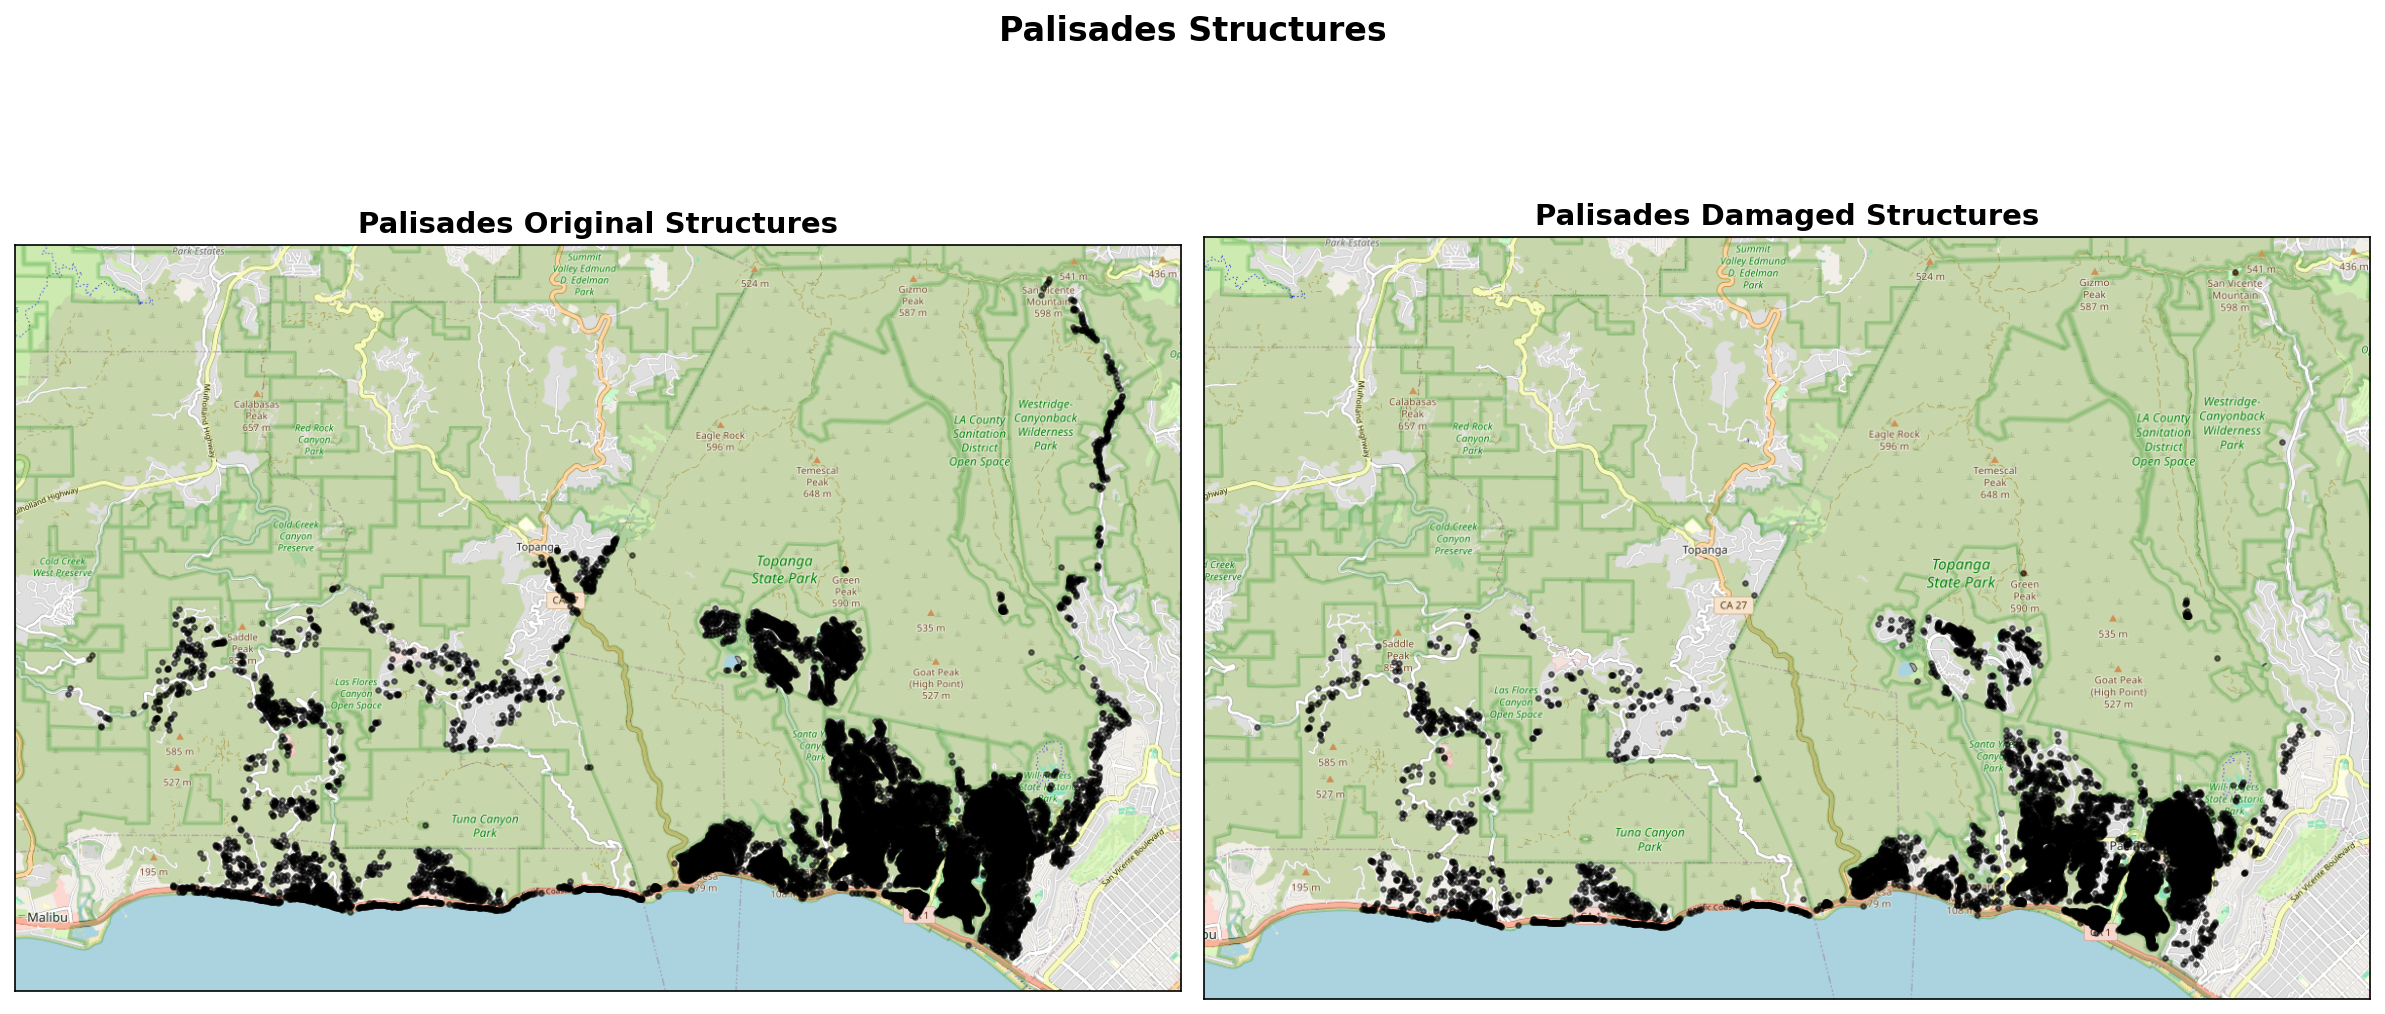

In [42]:
# Plot before and after building damaged buildings.
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Before filter.
dins_web.plot(ax=axes[0], alpha=0.5, color="black", markersize=5)
axes[0].set_title("Palisades Original Structures", fontsize=14, fontweight="bold")
axes[0].xaxis.set_visible(False)
axes[0].yaxis.set_visible(False)

# After filter.
dins_damaged_web.plot(ax=axes[1], alpha=0.5, color="black", markersize=5)
axes[1].set_title("Palisades Damaged Structures", fontsize=14, fontweight="bold")
axes[1].xaxis.set_visible(False)
axes[1].yaxis.set_visible(False)

# Add background tiles.
ctx.add_basemap(
    axes[0],
    crs=dins_damaged_web.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=13,
    attribution=False,
)
ctx.add_basemap(
    axes[1],
    crs=dins_damaged_web.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=13,
    attribution=False,
)

plt.suptitle("Palisades Structures", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "final_project_files/images/palisades_structures_filtered.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [43]:
# Plot all with background tile.
fig, ax = plt.subplots(figsize=(14, 12))

# Get bounds and set axis limits.
bounds = buildings_web.total_bounds
ax.set_xlim(bounds[0] - 500, bounds[2] + 500)
ax.set_ylim(bounds[1] - 500, bounds[3] + 500)

# Add background tile.
ctx.add_basemap(
    ax,
    crs=buildings_web.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=13,
    attribution=False,
)

# Plot building footprints on top.
fire_perimeter_web.plot(
    ax=ax, alpha=0.5, edgecolor="red", facecolor="none", linewidth=2
)
buildings_web.plot(ax=ax, alpha=0.5, color="blue")
dins_web.plot(ax=ax, alpha=0.5, color="black", markersize=3)

# Remove axis ticks.
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

ax.set_title("Palisades Study Area", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "final_project_files/images/palisades_study_area.png", dpi=300, bbox_inches="tight"
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Spatial Alignment

All vector datasets must be reprojected to match the exact Coordinate Reference System (CRS) of the Sentinel-2 optical grid. This ensures precise overlay for rasterization and tensor stacking.

In [44]:
# REPROJECT ALL VECTOR DATA TO TARGET CRS
# Target CRS matches Sentinel-2 data projection (UTM Zone 11N).
fire_perimeter_proj = fire_perimeter_gdf.to_crs(target_crs)
buildings_proj = buildings_gdf.to_crs(target_crs)
dins_proj = dins_damaged.to_crs(target_crs)

print(f"Fire Perimeter CRS: {fire_perimeter_proj.crs}")
print(f"Buildings CRS: {buildings_proj.crs}")
print(f"DINS CRS: {dins_proj.crs}")

Fire Perimeter CRS: EPSG:32611
Buildings CRS: EPSG:32611
DINS CRS: EPSG:32611


In [45]:
# CLIP VECTOR DATA TO STUDY AREA EXTENT
# Create bounding box in target CRS for clipping.
# Transform bbox coordinates to target CRS.
transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
bbox_min_x, bbox_min_y = transformer.transform(palisades_bbox[0], palisades_bbox[1])
bbox_max_x, bbox_max_y = transformer.transform(palisades_bbox[2], palisades_bbox[3])
bbox_proj = box(bbox_min_x, bbox_min_y, bbox_max_x, bbox_max_y)

# CLIP FIRE PERIMETER TO STUDY AREA
fire_perimeter_clipped = fire_perimeter_proj.clip(bbox_proj)

### Rasterization

Convert vector geometries to raster arrays matching the Sentinel-2 grid. This includes:
1. Fire perimeter to create the Area of Interest (AOI) mask.
2. Building footprints for the WUI infrastructure channel.
3. Destroyed structure locations for target mask generation.

In [46]:
# DEFINE RASTERIZATION PARAMETERS
# Use Sentinel-2 grid as reference for all rasterization.
raster_transform = from_bounds(
    sentinel_bounds[0],
    sentinel_bounds[1],
    sentinel_bounds[2],
    sentinel_bounds[3],
    sentinel_shape[1],
    sentinel_shape[0],
)

print(f"Output Shape: {sentinel_shape}")
print(f"Transform:\n{raster_transform}")

Output Shape: (801, 1173)
Transform:
| 20.00, 0.00, 341340.00|
| 0.00,-20.00, 3778960.00|
| 0.00, 0.00, 1.00|


In [47]:
# RASTERIZE FIRE PERIMETER TO CREATE ROI MASK
# Pixels inside fire perimeter are set to 1, outside to 0.


def rasterize_geometries(geometries, shape, transform, fill_value=0, default_value=1):
    """Rasterize vector geometries to a numpy array."""
    if len(geometries) == 0:
        return np.zeros(shape, dtype=np.uint8)

    # Create geometry-value pairs for rasterization.
    shapes = [(geom, default_value) for geom in geometries]

    # Rasterize.
    raster = features.rasterize(
        shapes=shapes,
        out_shape=shape,
        transform=transform,
        fill=fill_value,
        dtype=np.uint8,
    )

    return raster


# RASTERIZE FIRE PERIMETER
aoi_mask = rasterize_geometries(
    fire_perimeter_clipped.geometry, sentinel_shape, raster_transform
)

print(f"AOI Mask Shape: {aoi_mask.shape}")
print(f"Pixels Inside Fire Perimeter: {np.sum(aoi_mask == 1)}")

AOI Mask Shape: (801, 1173)
Pixels Inside Fire Perimeter: 243261


In [48]:
# Plot AOI mask on dNBR.
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# dNBR with ROI outline.
axes[0].imshow(dnbr, cmap="RdYlGn_r", vmin=-1, vmax=1.0)
axes[0].contour(aoi_mask, levels=[0.5], colors="red", linewidths=2)
axes[0].set_title("dNBR Fire Perimeter", fontsize=14, fontweight="bold")
axes[0].xaxis.set_visible(False)
axes[0].yaxis.set_visible(False)

# AOI mask only.
im = axes[1].imshow(aoi_mask, cmap="Blues")
axes[1].set_title("AOI Mask Fire Perimeter", fontsize=14, fontweight="bold")
axes[1].xaxis.set_visible(False)
axes[1].yaxis.set_visible(False)
plt.colorbar(im, ax=axes[1], fraction=0.05)

plt.suptitle("Palisades Raster Mask", fontsize=16, fontweight="bold", y=1)
plt.tight_layout()
plt.savefig(
    "final_project_files/images/palisades_raster_mask.png", dpi=300, bbox_inches="tight"
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [49]:
# BUFFER DINS POINTS FOR GPS DRIFT CORRECTION
# Apply 15-meter buffer to projected DINS points to account for field GPS error.
dins_buffered = dins_proj.copy()
dins_buffered.geometry = dins_buffered.geometry.buffer(15)

# Dissolve overlapping buffers to create unified damage zones.
# This prevents double-counting where multiple inspection points overlap.
dins_buffered_dissolved = dins_buffered.dissolve()

print(f"DINS Points Buffered: {len(dins_proj)}")
print(f"Dissolved Geometry Count: {len(dins_buffered_dissolved)}")

DINS Points Buffered: 7876
Dissolved Geometry Count: 1


Labels are constructed directly from buffered inspection points, NOT from building footprint geometries. This ensures the building footprint feature channel remains independent from the target labels, preventing target leakage.

In [50]:
# RASTERIZE ALL BUILDING FOOTPRINTS
# Convert complete infrastructure geometry into pixel grid.
# Baseline infrastructure channel for feature tensor.
building_raster = rasterize_geometries(
    buildings_proj.geometry, sentinel_shape, raster_transform
)

print(f"Building Raster Shape: {building_raster.shape}")
print(f"Pixels with Buildings: {np.sum(building_raster == 1)}")

Building Raster Shape: (801, 1173)
Pixels with Buildings: 34910


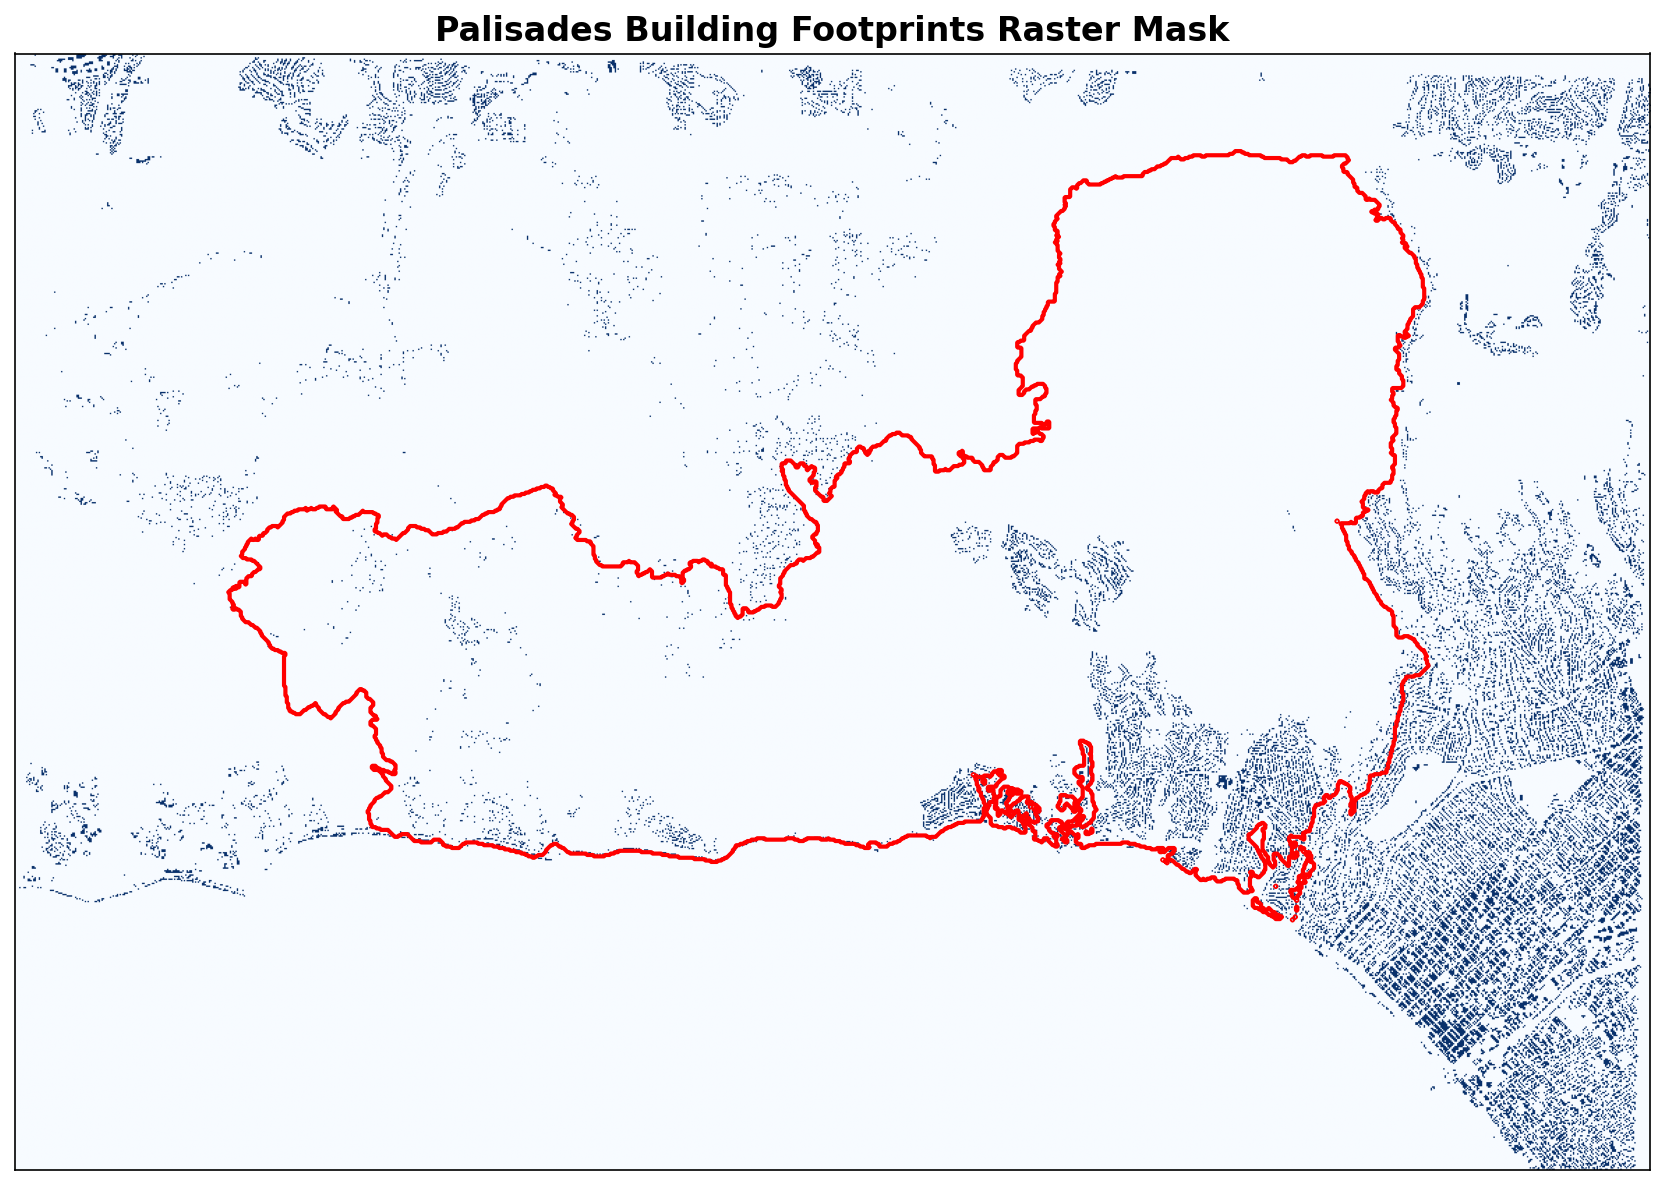

In [51]:
# Plot building footprints.
fig, ax = plt.subplots(figsize=(16, 8))

ax.imshow(building_raster, cmap="Blues")
ax.contour(aoi_mask, levels=[0.5], colors="red", linewidths=2)
ax.set_title(
    "Palisades Building Footprints Raster Mask", fontsize=16, fontweight="bold"
)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

plt.tight_layout()
plt.savefig(
    "final_project_files/images/buildings_mask.png", dpi=300, bbox_inches="tight"
)
plt.show()

In [52]:
# RASTERIZE DINS DAMAGE ZONES
# Convert buffered DINS inspection points directly to raster grid.
damaged_raster = rasterize_geometries(
    dins_buffered_dissolved.geometry,
    sentinel_shape,
    raster_transform,
)

print(f"Damaged Raster Shape: {damaged_raster.shape}")
print(f"Pixels in DINS Damage Zones: {np.sum(damaged_raster == 1)}")

Damaged Raster Shape: (801, 1173)
Pixels in DINS Damage Zones: 10111


Labels are derived from field inspection locations, NOT from building footprint polygons. This decouples the target mask from the building footprint feature channel, enabling valid model evaluation.

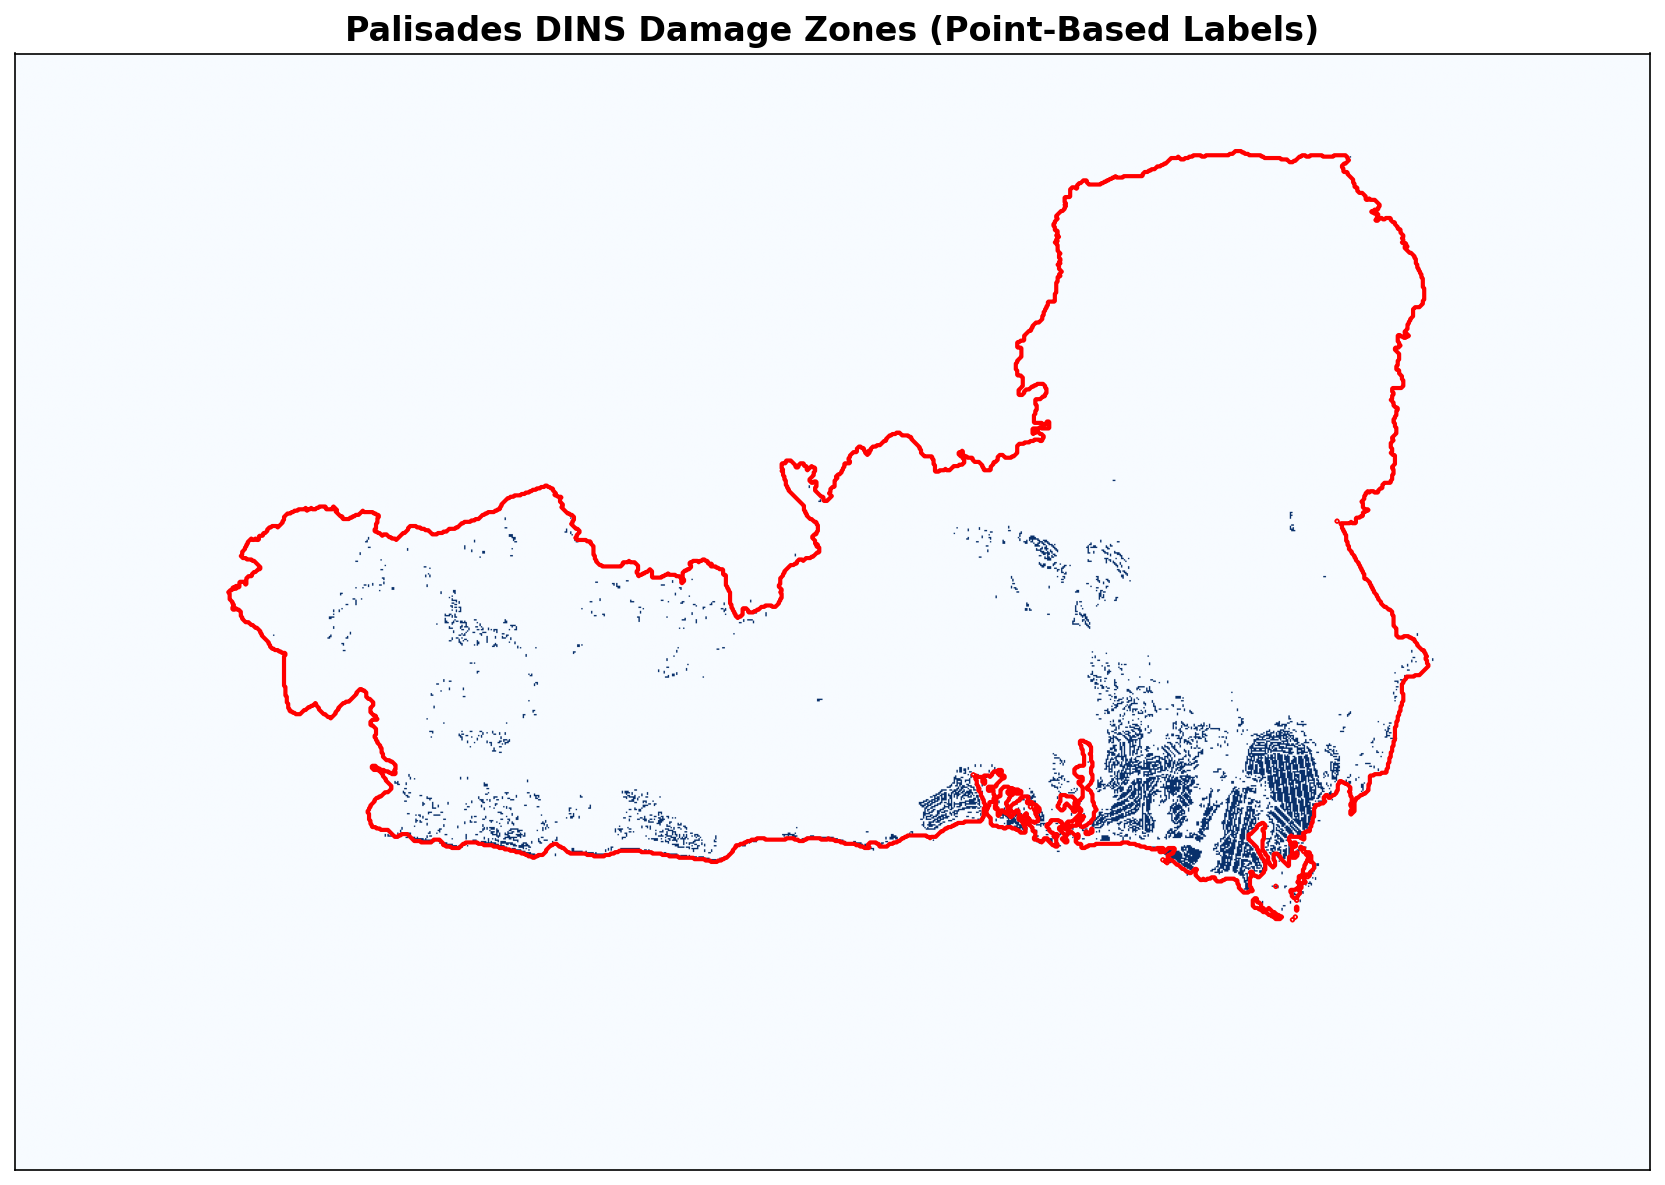

In [53]:
# Plot DINS-based damage zones.
fig, ax = plt.subplots(figsize=(16, 8))

ax.imshow(damaged_raster, cmap="Blues")
ax.contour(aoi_mask, levels=[0.5], colors="red", linewidths=2)
ax.set_title(
    "Palisades DINS Damage Zones (Point-Based Labels)", fontsize=16, fontweight="bold"
)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

plt.tight_layout()
plt.savefig(
    "final_project_files/images/dins_damage_zones.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [54]:
# Create base map centered on study area.
center_lat = np.mean([palisades_bbox[1], palisades_bbox[3]])
center_lon = np.mean([palisades_bbox[0], palisades_bbox[2]])

map = folium.Map(
    location=[center_lat, center_lon], zoom_start=13, tiles="OpenStreetMap"
)

# Convert raster to RGB image.
damaged_rgb = np.stack(
    [
        (damaged_raster * 255).astype(np.uint8),  # Red.
        np.zeros_like(damaged_raster, dtype=np.uint8),  # Green.
        np.zeros_like(damaged_raster, dtype=np.uint8),  # Blue.
    ],
    axis=-1,
)

# Add raster as overlay with layer control.
img_bounds = [
    [palisades_bbox[1], palisades_bbox[0]],
    [palisades_bbox[3], palisades_bbox[2]],
]

folium.raster_layers.ImageOverlay(
    image=damaged_rgb, bounds=img_bounds, opacity=0.75, name="Damaged Buildings Raster"
).add_to(map)

# Create DINS points layer.
dins_feature_group = folium.FeatureGroup(name="DINS Damaged Points", show=True)
dins_4326 = dins_proj.to_crs(epsg=4326)

for idx, row in dins_4326.iterrows():
    geom = row.geometry
    # Get coordinates.
    if geom.geom_type == "Point":
        lat, lon = geom.y, geom.x
    else:
        lat, lon = geom.centroid.y, geom.centroid.x

    # Create popup with damage info.
    popup_text = f"DINS Point {idx}"
    if "DAMAGE" in row.index:
        popup_text += f"<br>Damage: {row['DAMAGE']}"

    folium.CircleMarker(
        location=[lat, lon],
        radius=3,
        popup=folium.Popup(popup_text, max_width=200),
        tooltip=f"Point {idx}",
        color="blue",
        fill=True,
        fillColor="cyan",
        fillOpacity=0.8,
        weight=2,
    ).add_to(dins_feature_group)

dins_feature_group.add_to(map)

# Create fire perimeter layer.
perimeter_feature_group = folium.FeatureGroup(name="Fire Perimeter", show=True)
fire_perimeter_4326 = fire_perimeter_gdf.to_crs(epsg=4326)

for geom in fire_perimeter_4326.geometry:
    coords = [(lat, lon) for lon, lat in geom.exterior.coords]
    folium.PolyLine(locations=coords, color="red", weight=3, opacity=0.75).add_to(
        perimeter_feature_group
    )

perimeter_feature_group.add_to(map)

# Add layer control to toggle on/off.
folium.LayerControl(position="topright", collapsed=False).add_to(map)

# Display.
map

Output hidden; open in https://colab.research.google.com to view.

### Leaking dNBR Target (Reference Only, Not Used for Modeling)

**This section calculates a dNBR-derived target mask for documentation and comparison purposes only.** This target is deliberately NOT used for model training or evaluation because it introduces target leakage: dNBR is an input feature (Channel 0 of the tensor), and using it to generate labels would allow the model to learn a trivial threshold rather than genuine predictive relationships.

The calculation below applies localized Otsu thresholding on dNBR within the AOI and combines it with the DINS structural damage mask via Boolean union. This leaking target is saved separately as `leaked_y_target.npy` for reference.

**The actual modeling target** (`y_target.npy`) uses ONLY the DINS field inspection labels, consistent with the methodological approach described in the proposal.

In [55]:
# GET DNBR VALUES WITHIN ROI ONLY
# Localized thresholding prevents unburned areas from biasing Otsu calculation.
dnbr_array = dnbr_masked.values

# APPLY AOI MASK TO DNBR
dnbr_roi = np.where(aoi_mask == 1, dnbr_array, np.nan)

# GET VALID PIXELS FOR OTSU CALCULATION
# Remove NaN values from calculation.
valid_dnbr_pixels = dnbr_roi[~np.isnan(dnbr_roi)]

print(f"Valid Pixels in AOI: {len(valid_dnbr_pixels)}")
print(
    f"dNBR Range in AOI: [{np.min(valid_dnbr_pixels):.3f}, {np.max(valid_dnbr_pixels):.3f}]"
)
print(f"dNBR Mean in AOI: {np.mean(valid_dnbr_pixels):.3f}")

Valid Pixels in AOI: 243247
dNBR Range in AOI: [-0.634, 0.968]
dNBR Mean in AOI: 0.345


In [56]:
# CALCULATE OTSU THRESHOLD ON LOCALIZED DNBR
# Otsu algorithm finds optimal threshold to separate burn from non-burn.
otsu_threshold = threshold_otsu(valid_dnbr_pixels)

print(f"Calculated Otsu Threshold: {otsu_threshold:.4f}")

Calculated Otsu Threshold: 0.3326


In [57]:
# GENERATE VEGETATION BURN MASK USING OTSU THRESHOLD
# Pixels above threshold within ROI are classified as burned vegetation.
vegetation_burn_mask = (dnbr_array > otsu_threshold) & (aoi_mask == 1)
vegetation_burn_mask = vegetation_burn_mask.astype(np.uint8)

print(f"Burned Vegetation Pixels: {np.sum(vegetation_burn_mask == 1)}")
print(
    f"Percentage of ROI: {np.sum(vegetation_burn_mask) / np.sum(aoi_mask) * 100:.1f}%"
)

Burned Vegetation Pixels: 131786
Percentage of ROI: 54.2%


In [58]:
# CREATE FINAL TARGET MASK USING BOOLEAN UNION
# A pixel is damaged if (dNBR > Otsu) OR (contains damaged structure).
leaked_y_target = np.logical_or(vegetation_burn_mask, damaged_raster).astype(np.uint8)

# APPLY ROI MASK TO FINAL TARGET
# Ensure only pixels within fire perimeter are considered.
leaked_y_target = leaked_y_target * aoi_mask

print(f"Leaking Target Shape: {leaked_y_target.shape}")
print(f"Leaking Target Damaged Pixels: {np.sum(leaked_y_target == 1)}")
print(f"Leaking Target Damaged % of ROI: {np.sum(leaked_y_target) / np.sum(aoi_mask) * 100:.1f}%")
print(
    f"Leaking Target Class Distribution: 0 (Unburned) = {np.sum(leaked_y_target == 0)}, 1 (Damaged) = {np.sum(leaked_y_target == 1)}"
)

Leaking Target Shape: (801, 1173)
Leaking Target Damaged Pixels: 140978
Leaking Target Damaged % of ROI: 58.0%
Leaking Target Class Distribution: 0 (Unburned) = 798595, 1 (Damaged) = 140978


In [59]:
# LABEL CONSTRUCTION SUMMARY
print("DINS LABEL CONSTRUCTION")
print(f"CAL FIRE Inspection Points: {len(dins_proj)}")
print("Buffer Radius Applied: 15 meters")
print(f"Total DINS Damage Zone Pixels: {np.sum(damaged_raster == 1)}")

print("\nFEATURE-LABEL INDEPENDENCE CHECK")
# Verify that damage labels are NOT perfectly correlated with building footprints.
# If labels were derived from footprint geometries, overlap would be 100%.
label_and_building = np.sum((damaged_raster == 1) & (building_raster == 1))
label_total = np.sum(damaged_raster == 1)
overlap_pct = (label_and_building / label_total) * 100 if label_total > 0 else 0
print(f"Damage Pixels Overlapping Buildings: {label_and_building}")
print(f"Overlap Percentage: {overlap_pct:.1f}%")
print("(Values < 100% confirm labels are NOT derived from building geometries)")

print("\nBOOLEAN UNION CONTRIBUTION (REFERENCE ONLY)")
# Pixels added by DINS zones that Otsu missed.
dins_additions = np.sum((leaked_y_target == 1) & (vegetation_burn_mask == 0))
print(f"Pixels Added by DINS Zones (Otsu missed): {dins_additions}")

DINS LABEL CONSTRUCTION
CAL FIRE Inspection Points: 7876
Buffer Radius Applied: 15 meters
Total DINS Damage Zone Pixels: 10111

FEATURE-LABEL INDEPENDENCE CHECK
Damage Pixels Overlapping Buildings: 3872
Overlap Percentage: 38.3%
(Values < 100% confirm labels are NOT derived from building geometries)

BOOLEAN UNION CONTRIBUTION (REFERENCE ONLY)
Pixels Added by DINS Zones (Otsu missed): 9192


### DINS-Only Target Mask (Used for Modeling)

The actual modeling target is constructed exclusively from CAL FIRE DINS field inspection points. This avoids target leakage by keeping all spectral indices (dNBR) strictly as input features, never as label-generating mechanisms. The DINS-only target is saved as `y_target.npy` and loaded by `02_modeling_approach_new.ipynb`.

In [60]:
# DINS-ONLY TARGET MASK (USED FOR MODELING)
# Constructed exclusively from buffered CAL FIRE DINS inspection points.
# dNBR is NOT used in label generation to prevent target leakage.
y_target = damaged_raster.copy()

print(f"DINS-Only Target Shape: {y_target.shape}")
print(f"Damaged Pixels: {np.sum(y_target == 1):,}")
print(f"Intact Pixels: {np.sum(y_target == 0):,}")
print(f"Damage % of AOI: {np.sum(y_target[aoi_mask == 1]) / np.sum(aoi_mask) * 100:.2f}%")
print(f"Class Imbalance Ratio: {np.sum(y_target == 0) / max(np.sum(y_target == 1), 1):.1f}:1")

DINS-Only Target Shape: (801, 1173)
Damaged Pixels: 10,111
Intact Pixels: 929,462
Damage % of AOI: 4.04%
Class Imbalance Ratio: 91.9:1


**Label Construction Methodology**: The target mask uses CAL FIRE Damage Inspection (DINS) field assessment points as ground truth for structural damage. A 15-meter buffer is applied to each inspection point to account for GPS positioning error during field data collection. These buffered point geometries are rasterized directly to create the structural damage label mask.

**Feature-Label Independence**: This approach deliberately avoids joining DINS points to Microsoft Building Footprints before rasterization. While such a join would produce cleaner building-shaped labels, it would create a methodological problem: the building footprint feature channel (used as model input) would become perfectly correlated with the target labels (y=1 would always imply building=1). This correlation would allow the model to achieve artificially high performance by learning a trivial relationship rather than discovering genuine spectral and topographic predictors of fire damage.

By using point-based labels, the overlap between damage zones and building footprints is empirically determined rather than guaranteed by construction. The model must learn whether the combination of spectral signatures (dNBR, SWIR), topographic context (Aspect), and infrastructure presence (Building Footprints) collectively predict field-verified structural damage outcomes.

**Buffer Radius Selection**: The 15-meter buffer balances GPS drift correction against false positive risk. In the Santa Monica Mountains, structures are often set back from roads where inspectors may have recorded GPS coordinates. A larger buffer would capture more structures but risks labeling adjacent undamaged properties as damaged.

The `leaked_y_target` (leaking reference target) found additional burned vegetation pixels via Otsu thresholding. The actual `y_target` used for modeling contains only the DINS-derived damage pixels. The difference between the two quantifies how much the dNBR Otsu threshold would have inflated labels with spectrally-derived information that overlaps with input features.

**7876 (Raw Points)**: CAL FIRE inspectors recorded 7,876 destroyed structures.

**6313 (Strict Join)**: Without a buffer captures 6,313 homes, losing 1,563 structures (a 20% data loss) due to GPS drift.

**7196 (Buffered Join)**: The 15-meter buffer captures 7,196 homes, recovering 883 destroyed structures.

This currently captures about 91% of the dataset between field data and computer-vision footprints.

The buffer will not be increased from 15 meters due to the fact that in the Santa Monica Mountains homes may be hundreds of feet away from the street where the inspector may have recorded the GPS point. If the buffer is increased to catch the rest of the 680, the circle risks intersecting with a neighboring, unburned home, creating a false positive label. Also, an inspector will log a destroyed RV, a large tool shed, or an unpermitted WUI outbuilding, so Microsoft building footprints may exclude these non-permanent structures.

### Feature Tensor Stacking

The multi-channel feature tensor is assembled by stacking all preprocessed layers. In addition to the four original derived features, the raw pre-fire and post-fire NIR and SWIR bands are included as separate channels. This allows the U-Net to learn its own spectral change representations beyond the hand-engineered dNBR index, while retaining dNBR as an explicit domain-knowledge channel.

- **Channel 0**: Delta Normalized Burn Ratio (dNBR)
- **Channel 1**: Post-Fire Shortwave-Infrared (SWIR) reflectance
- **Channel 2**: DEM-derived Aspect (normalized)
- **Channel 3**: Building footprint presence (binary)
- **Channel 4**: Pre-Fire Near-Infrared (NIR) reflectance
- **Channel 5**: Pre-Fire Shortwave-Infrared (SWIR) reflectance
- **Channel 6**: Post-Fire Near-Infrared (NIR) reflectance

All channels are aligned to the same spatial grid and normalized for neural network input.

In [61]:
# PREPARE INDIVIDUAL CHANNELS
# Ensure all arrays have matching shapes.

# PERCENTILE NORMALIZATION HELPER
# Clips to 2nd/98th percentile range and scales to [0, 1].

def percentile_normalize(array, low_pct = 2, high_pct = 98):
    """Normalize array to [0, 1] using percentile clipping on nonzero pixels."""
    nonzero_mask = array > 0
    if np.sum(nonzero_mask) == 0:
        return array
    p_low = np.percentile(array[nonzero_mask], low_pct)
    p_high = np.percentile(array[nonzero_mask], high_pct)
    return np.clip((array - p_low) / (p_high - p_low + 1e-10), 0, 1)


# Channel 0: dNBR (already computed).
channel_dnbr = dnbr_array.copy()
channel_dnbr = np.nan_to_num(channel_dnbr, nan=0.0)

# Channel 1: Post-Fire SWIR.
channel_swir = post_swir.values.copy()
channel_swir = np.nan_to_num(channel_swir, nan=0.0)
channel_swir = percentile_normalize(channel_swir)

# Channel 2: DEM Aspect (normalized to 0-1).
channel_aspect = aspect_normalized.copy()
channel_aspect = np.nan_to_num(channel_aspect, nan=0.0)

# Channel 3: Building Footprints (binary).
channel_buildings = building_raster.astype(float)

# Channel 4: Pre-Fire NIR.
channel_pre_nir = pre_nir.values.copy()
channel_pre_nir = np.nan_to_num(channel_pre_nir, nan=0.0)
channel_pre_nir = percentile_normalize(channel_pre_nir)

# Channel 5: Pre-Fire SWIR.
channel_pre_swir = pre_swir.values.copy()
channel_pre_swir = np.nan_to_num(channel_pre_swir, nan=0.0)
channel_pre_swir = percentile_normalize(channel_pre_swir)

# Channel 6: Post-Fire NIR.
channel_post_nir = post_nir.values.copy()
channel_post_nir = np.nan_to_num(channel_post_nir, nan=0.0)
channel_post_nir = percentile_normalize(channel_post_nir)

print("ORIGINAL DERIVED CHANNELS")
print(
    f"dNBR Shape: {channel_dnbr.shape}, Range: [{channel_dnbr.min():.3f}, {channel_dnbr.max():.3f}]"
)
print(
    f"SWIR Shape: {channel_swir.shape}, Range: [{channel_swir.min():.3f}, {channel_swir.max():.3f}]"
)
print(
    f"Aspect Shape: {channel_aspect.shape}, Range: [{channel_aspect.min():.3f}, {channel_aspect.max():.3f}]"
)
print(
    f"Buildings Shape: {channel_buildings.shape}, Range: [{channel_buildings.min():.0f}, {channel_buildings.max():.0f}]"
)

print("\nRAW MULTI-TEMPORAL BAND CHANNELS")
print(
    f"Pre-NIR Shape: {channel_pre_nir.shape}, Range: [{channel_pre_nir.min():.3f}, {channel_pre_nir.max():.3f}]"
)
print(
    f"Pre-SWIR Shape: {channel_pre_swir.shape}, Range: [{channel_pre_swir.min():.3f}, {channel_pre_swir.max():.3f}]"
)
print(
    f"Post-NIR Shape: {channel_post_nir.shape}, Range: [{channel_post_nir.min():.3f}, {channel_post_nir.max():.3f}]"
)

ORIGINAL DERIVED CHANNELS
dNBR Shape: (801, 1173), Range: [-1.553, 1.212]
SWIR Shape: (801, 1173), Range: [0.000, 1.000]
Aspect Shape: (801, 1173), Range: [0.000, 1.000]
Buildings Shape: (801, 1173), Range: [0, 1]

RAW MULTI-TEMPORAL BAND CHANNELS
Pre-NIR Shape: (801, 1173), Range: [0.000, 1.000]
Pre-SWIR Shape: (801, 1173), Range: [0.000, 1.000]
Post-NIR Shape: (801, 1173), Range: [0.000, 1.000]


In [62]:
# STACK CHANNELS INTO MULTI-CHANNEL TENSOR
# Final tensor shape: (Height, Width, 7).
X_tensor = np.stack(
    [
        channel_dnbr,
        channel_swir,
        channel_aspect,
        channel_buildings,
        channel_pre_nir,
        channel_pre_swir,
        channel_post_nir,
    ],
    axis=-1,
)

print(f"X_tensor Shape: {X_tensor.shape}")
print(f"X_tensor Data Type: {X_tensor.dtype}")
print(f"Memory Size: {X_tensor.nbytes / 1e6:.2f} MB\n")
print("DERIVED FEATURE CHANNELS")
print("Channel 0: Delta NBR (dNBR)")
print("Channel 1: Post-Fire SWIR (normalized)")
print("Channel 2: DEM Aspect (normalized)")
print("Channel 3: Building Footprints (binary)")
print("\nRAW MULTI-TEMPORAL BAND CHANNELS")
print("Channel 4: Pre-Fire NIR (normalized)")
print("Channel 5: Pre-Fire SWIR (normalized)")
print("Channel 6: Post-Fire NIR (normalized)")

X_tensor Shape: (801, 1173, 7)
X_tensor Data Type: float64
Memory Size: 52.62 MB

DERIVED FEATURE CHANNELS
Channel 0: Delta NBR (dNBR)
Channel 1: Post-Fire SWIR (normalized)
Channel 2: DEM Aspect (normalized)
Channel 3: Building Footprints (binary)

RAW MULTI-TEMPORAL BAND CHANNELS
Channel 4: Pre-Fire NIR (normalized)
Channel 5: Pre-Fire SWIR (normalized)
Channel 6: Post-Fire NIR (normalized)


### Export Preprocessed Data

The feature tensor and target mask are saved as NumPy binary files (.npy) for loading during model training. Metadata is preserved in JSON file for reproducibility.

In [63]:
# SAVE FEATURE TENSOR
model_path = Path("final_project_files/model")
model_path.mkdir(parents=True, exist_ok=True)

X_output_path = model_path / "X_tensor.npy"
np.save(X_output_path, X_tensor)

print(f"Tensor Saved: {X_output_path}")
print(f"File Size: {os.path.getsize(X_output_path) / 1e6:.2f} MB")

Tensor Saved: final_project_files/model/X_tensor.npy
File Size: 52.62 MB


In [64]:
# SAVE DINS-ONLY TARGET MASK (USED FOR MODELING)
y_output_path = model_path / "y_target.npy"
np.save(y_output_path, y_target)

print(f"Target Mask Saved: {y_output_path}")
print(f"File Size: {os.path.getsize(y_output_path) / 1e6:.2f} MB")

Target Mask Saved: final_project_files/model/y_target.npy
File Size: 0.94 MB


In [65]:
# SAVE AOI MASK FOR REFERENCE
roi_output_path = model_path / "aoi_mask.npy"
np.save(roi_output_path, aoi_mask)

print(f"AOI Mask Saved: {roi_output_path}")
print(f"File Size: {os.path.getsize(roi_output_path) / 1e6:.2f} MB")

AOI Mask Saved: final_project_files/model/aoi_mask.npy
File Size: 0.94 MB


In [66]:
# SAVE LEAKING DNBR UNION TARGET (REFERENCE ONLY)
# Boolean union of Otsu dNBR threshold and DINS points.
# NOT used for modeling due to target leakage (dNBR is an input feature).
leaked_output_path = model_path / "leaked_y_target.npy"
np.save(leaked_output_path, leaked_y_target)

print(f"Leaking Union Target Saved: {leaked_output_path}")
print(f"File Size: {os.path.getsize(leaked_output_path) / 1e6:.2f} MB")
print("WARNING: This file is for reference only. Do NOT use for model training.")

Leaking Union Target Saved: final_project_files/model/leaked_y_target.npy
File Size: 0.94 MB


In [67]:
# SAVE PREPROCESSING METADATA

metadata = {
    "study_area": {
        "name": "2025 Los Angeles Palisades Fire",
        "bbox_wgs84": palisades_bbox,
        "crs": target_crs,
        "resolution_meters": target_resolution,
    },
    "temporal_windows": {
        "pre_fire": {"start": pre_fire_start, "end": pre_fire_end},
        "post_fire": {"start": post_fire_start, "end": post_fire_end},
    },
    "sentinel_scenes": {
        "pre_fire": best_pre_fire.id if best_pre_fire else None,
        "post_fire": best_post_fire.id if best_post_fire else None,
    },
    "tensor_info": {
        "shape": list(X_tensor.shape),
        "channels": [
            "dNBR",
            "Post-Fire SWIR",
            "DEM Aspect",
            "Building Footprints",
            "Pre-Fire NIR",
            "Pre-Fire SWIR",
            "Post-Fire NIR"
        ],
        "dtype": str(X_tensor.dtype),
    },
    "multi_temporal_bands": {
        "bands": ["pre_nir", "pre_swir", "post_nir", "post_swir"],
        "normalization": "2nd_98th_percentile",
        "rationale": "Raw bands allow U-Net to learn spectral change representations beyond hand-engineered dNBR",
    },
    "target_info": {
        "shape": list(y_target.shape),
        "otsu_threshold": float(otsu_threshold),
        "positive_class_pixels": int(np.sum(y_target == 1)),
        "label_source": "DINS_only",
        "negative_class_pixels": int(np.sum(y_target == 0)),
        "leaking_union_saved_separately": True,
    },
    "label_construction": {
        "method": "dins_only_point_based_buffering",
        "buffer_radius_meters": 15,
        "rationale": "Labels derived exclusively from DINS points. dNBR is NOT used in label generation to prevent target leakage since dNBR is Channel 0 of the input tensor.",
    },
    "data_sources": {
        "optical": "Sentinel-2 L2A via Element 84 Earth Search STAC",
        "dem": "USGS 3DEP via Planetary Computer STAC",
        "fire_perimeter": "NIFC / LA County Open Data",
        "buildings": "LA GeoHub Building Footprints",
        "damage_inspection": "CAL FIRE DINS",
    },
}

metadata_path = model_path / "preprocessing_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata Saved: {metadata_path}")

Metadata Saved: final_project_files/model/preprocessing_metadata.json


In [68]:
# FINAL PREPROCESSING SUMMARY
print("OUTPUT FILES")
print(f"Feature Tensor: {X_output_path}")
print(f"Target Mask (DINS-Only): {y_output_path}")
print(f"ROI Mask: {roi_output_path}")
print(f"Leaking Union Reference: {leaked_y_target}")
print(f"Metadata: {metadata_path}")
print("\nTENSOR SPECS")
print(f"X_tensor Shape: {X_tensor.shape} (Height x Width x 7 Channels)")
print("  Channels 0-3: Derived features (dNBR, Post-SWIR, Aspect, Buildings)")
print("  Channels 4-6: Raw multi-temporal bands (Pre-NIR, Pre-SWIR, Post-NIR)")
print(f"y_target Shape: {y_target.shape} (DINS-Only, Height x Width)")
print(f"Spatial Resolution: {target_resolution} meters")
print(f"Coordinate Reference System: {target_crs}")
print("\nCLASS DISTRIBUTION")
print(f"Class 0 (Intact): {np.sum(y_target == 0):,} pixels")
print(f"Class 1 (DINS Damaged): {np.sum(y_target == 1):,} pixels")
print(
    f"Class Imbalance Ratio: {np.sum(y_target == 0) / max(np.sum(y_target == 1), 1):.1f}:1"
)
print("\nDNBR OTSU THRESHOLD (REFERENCE ONLY, NOT USED IN LABELS)")
print(f"Calculated dNBR Threshold: {otsu_threshold:.4f}")

OUTPUT FILES
Feature Tensor: final_project_files/model/X_tensor.npy
Target Mask (DINS-Only): final_project_files/model/y_target.npy
ROI Mask: final_project_files/model/aoi_mask.npy
Leaking Union Reference: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Metadata: final_project_files/model/preprocessing_metadata.json

TENSOR SPECS
X_tensor Shape: (801, 1173, 7) (Height x Width x 7 Channels)
  Channels 0-3: Derived features (dNBR, Post-SWIR, Aspect, Buildings)
  Channels 4-6: Raw multi-temporal bands (Pre-NIR, Pre-SWIR, Post-NIR)
y_target Shape: (801, 1173) (DINS-Only, Height x Width)
Spatial Resolution: 20 meters
Coordinate Reference System: EPSG:32611

CLASS DISTRIBUTION
Class 0 (Intact): 929,462 pixels
Class 1 (DINS Damaged): 10,111 pixels
Class Imbalance Ratio: 91.9:1

DNBR OTSU THRESHOLD (REFERENCE ONLY, NOT USED IN LABELS)
Calculated dNBR Threshold: 0.3326


In [69]:
# VERIFY FEATURE-LABEL INDEPENDENCE
# This cell confirms methodological fix was applied correctly.
# Calculate correlation between building footprint feature and damage labels.
building_flat = building_raster.flatten()
damage_flat = damaged_raster.flatten()

# Pearson correlation.
correlation = np.corrcoef(building_flat, damage_flat)[0, 1]
print(f"Pearson Correlation (Building Feature vs Damage Label): {correlation:.4f}")

# If using footprint-based labels, correlation would be very high (>0.9).
# With point-based labels, correlation should be moderate (<0.5).
if correlation > 0.8:
    print("WARNING: High correlation.")
else:
    print("PASS: Moderate correlation for feature-label independence.")

# Additional check: percentage of damage pixels on buildings.
damage_on_buildings = np.sum((damaged_raster == 1) & (building_raster == 1))
total_damage = np.sum(damaged_raster == 1)
pct_on_buildings = (damage_on_buildings / total_damage) * 100 if total_damage > 0 else 0

# 100% would indicate footprint-based label construction.
print(f"\nDamage Pixels on Building Footprints: {pct_on_buildings:.1f}%")

Pearson Correlation (Building Feature vs Damage Label): 0.1907
PASS: Moderate correlation for feature-label independence.

Damage Pixels on Building Footprints: 38.3%


### Data Quality Assessment

This section provides visual verification of the preprocessing pipeline outputs to ensure data integrity before model training.

In [70]:
# VISUALIZE PREPROCESSED LAYERS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# DNBR VISUALIZATION
im0 = axes[0, 0].imshow(channel_dnbr, cmap="RdYlGn_r", vmin=-1, vmax=1.0)
axes[0, 0].set_title("Delta NBR (dNBR)", fontweight="bold")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.05)

# POST-FIRE SWIR VISUALIZATION
im1 = axes[0, 1].imshow(channel_swir, cmap="gray")
axes[0, 1].set_title("Post-Fire SWIR (Normalized)", fontweight="bold")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.05)

# DEM ASPECT VISUALIZATION
im2 = axes[0, 2].imshow(channel_aspect, cmap="hsv")
axes[0, 2].set_title("DEM Aspect (Normalized)", fontweight="bold")
plt.colorbar(im2, ax=axes[0, 2], fraction=0.05)

# BUILDING FOOTPRINTS VISUALIZATION
im3 = axes[1, 0].imshow(channel_buildings, cmap="binary")
axes[1, 0].set_title("Building Footprints", fontweight="bold")

# ROI MASK VISUALIZATION
im4 = axes[1, 1].imshow(aoi_mask, cmap="Blues")
axes[1, 1].set_title("Fire Perimeter ROI", fontweight="bold")

# TARGET MASK VISUALIZATION
im5 = axes[1, 2].imshow(y_target, cmap="Reds")
axes[1, 2].set_title("Target Mask (DINS-Only)", fontweight="bold")

for ax in axes.flat:
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

plt.tight_layout()
plt.savefig(
    "final_project_files/images/preprocessing_visualization.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

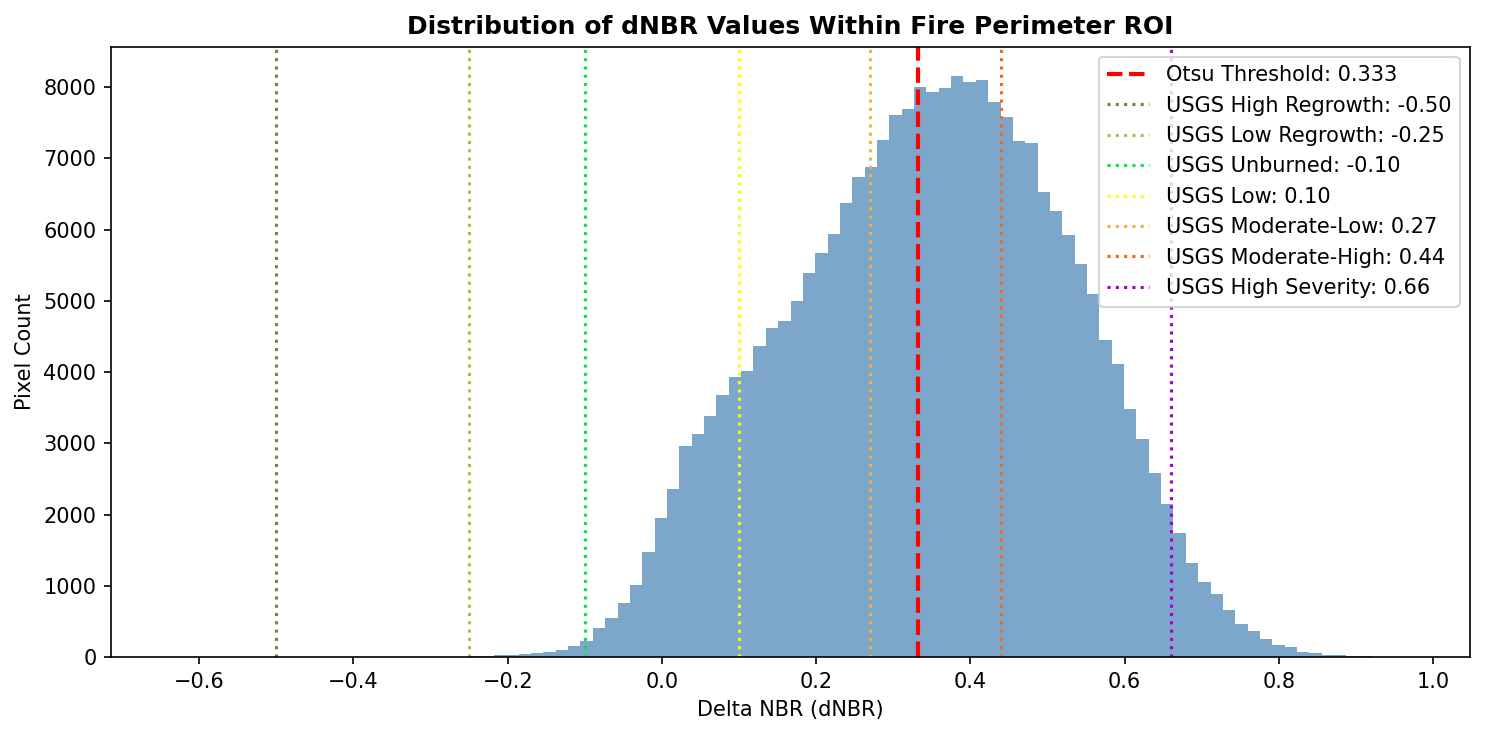

In [71]:
# HISTOGRAM OF DNBR VALUES WITHIN ROI
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(valid_dnbr_pixels, bins=100, color="steelblue", edgecolor="none", alpha=0.7)
ax.axvline(
    x=otsu_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Otsu Threshold: {otsu_threshold:.3f}",
)
ax.axvline(
    x=-0.5,
    color="#778835",
    linestyle=":",
    linewidth=1.5,
    label="USGS High Regrowth: -0.50",
)
ax.axvline(
    x=-0.25,
    color="#A7C050",
    linestyle=":",
    linewidth=1.5,
    label="USGS Low Regrowth: -0.25",
)
ax.axvline(
    x=-0.1,
    color="#0BE344",
    linestyle=":",
    linewidth=1.5,
    label="USGS Unburned: -0.10",
)
ax.axvline(
    x=0.1,
    color="#F8FC11",
    linestyle=":",
    linewidth=1.5,
    label="USGS Low: 0.10",
)
ax.axvline(
    x=0.27,
    color="#F8B140",
    linestyle=":",
    linewidth=1.5,
    label="USGS Moderate-Low: 0.27",
)
ax.axvline(
    x=0.44,
    color="#F8671A",
    linestyle=":",
    linewidth=1.5,
    label="USGS Moderate-High: 0.44",
)
ax.axvline(
    x=0.66,
    color="#A600D4",
    linestyle=":",
    linewidth=1.5,
    label="USGS High Severity: 0.66",
)

ax.set_xlabel("Delta NBR (dNBR)")
ax.set_ylabel("Pixel Count")
ax.set_title("Distribution of dNBR Values Within Fire Perimeter ROI", fontweight="bold")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(
    "final_project_files/images/dnbr_histogram.png", dpi=300, bbox_inches="tight"
)
plt.show()

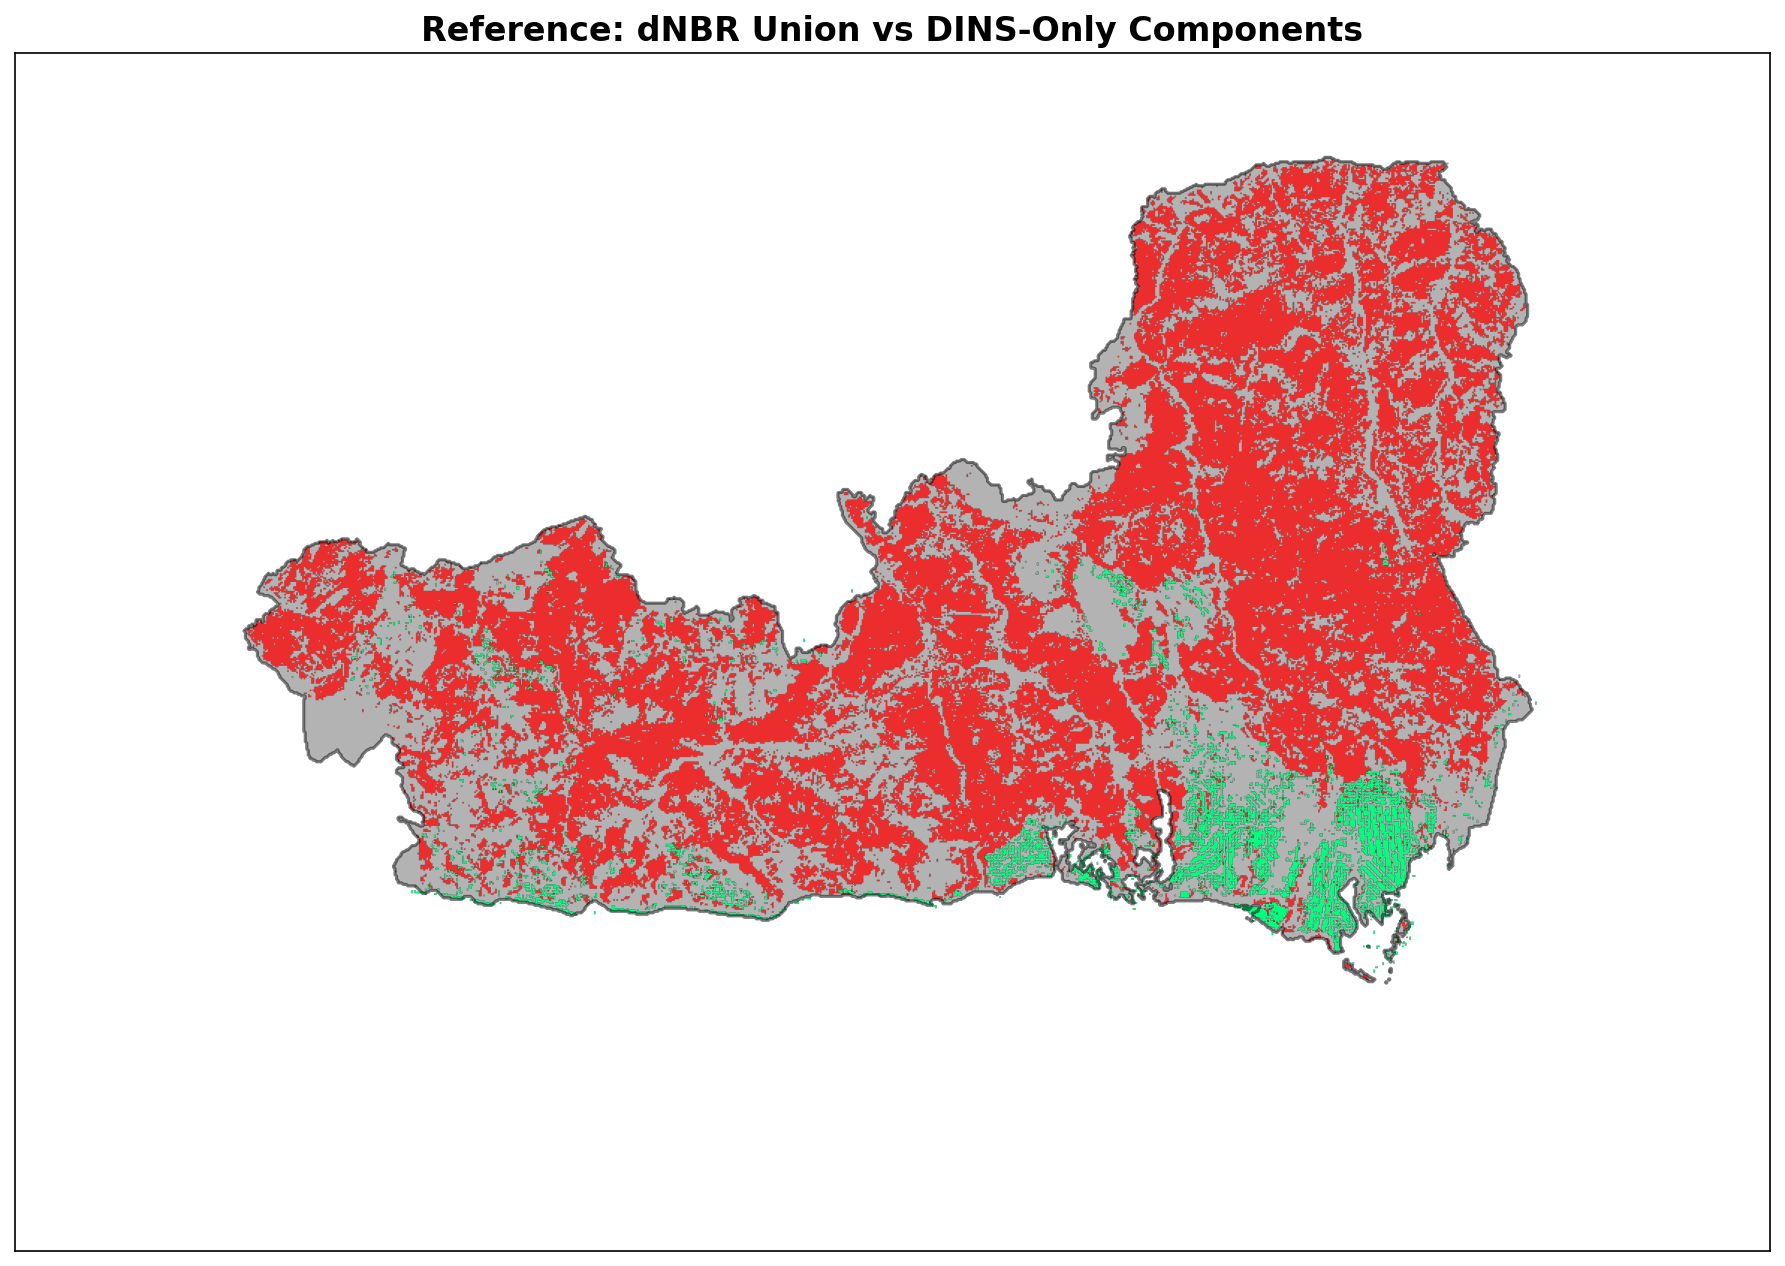

In [72]:
# Composite target mask.
fig, ax = plt.subplots(figsize=(12, 10))

# Background.
# Render area of interest mask in light gray to define unburned region.
ax.imshow(aoi_mask, cmap="Greys", alpha=0.3)

# Vegetation burn scar.
# Mask out unburned pixels so only destroyed canopy renders in dark red.
veg_masked = np.ma.masked_where(vegetation_burn_mask == 0, vegetation_burn_mask == 1)
ax.imshow(veg_masked, cmap="autumn", alpha=0.75)

# Damaged infrastructure.
# Mask out safe pixels to overlay destroyed WUI footprints in bright yellow.
buildings_masked = np.ma.masked_where(damaged_raster == 0, damaged_raster == 1)
ax.imshow(buildings_masked, cmap="winter_r", alpha=1.0)

# Boundary.
# Draw operational fire perimeter as a solid outline using a contour extraction.
ax.contour(aoi_mask, levels=[0.5], colors="black", linewidths=1.5, alpha=0.5)

ax.set_title("Reference: dNBR Union vs DINS-Only Components", fontsize=16, fontweight="bold")
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

plt.tight_layout()
plt.savefig(
    "final_project_files/images/final_target_mask.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### AI Use

Used free model Claude Haiku 4.5 for debugging and assisting with defining functions.